In [2]:
print("Hello World")

Hello World


## Package import

In [3]:
# ============================================================
# 🔧 SYSTEM & UTILITIES
# ============================================================
import os
import gc
import re
import io
import psutil
import json
import joblib
import pickle
import random
import requests
import itertools
import warnings
import holidays
import urllib.request as urlreq
from tqdm import tqdm
from dotenv import load_dotenv
from datetime import datetime, timedelta, date
from dateutil.relativedelta import relativedelta

# Suppress warnings
warnings.filterwarnings('ignore')

# ============================================================
# 📦 CORE PYTHON & DATA HANDLING
# ============================================================
import numpy as np
import pandas as pd
import datetime as dt

# ============================================================
# 📊 EXPLORATORY DATA ANALYSIS (EDA) & VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno
from pandas.plotting import lag_plot, autocorrelation_plot
from scipy import stats
from math import sqrt
from IPython.display import display, HTML

# Enable inline plotting
%matplotlib inline

# ============================================================
# ⚙️ DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_classif
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ============================================================
# 🧠 MACHINE LEARNING MODELS
# ============================================================
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, make_scorer
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# ============================================================
# 🔮 TIME SERIES & FORECASTING
# ============================================================
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================================
# 🧬 DEEP LEARNING (TENSORFLOW / KERAS)
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional, BatchNormalization,
    Conv1D, MaxPooling1D, Flatten
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
import keras_tuner as kt

# ============================================================
# 🧮 STATISTICAL ANALYSIS
# ============================================================
import scipy.stats as stats
from scipy.stats import zscore, pearsonr, spearmanr

# ============================================================
# 🗂 DASHBOARDING & FRONT-END (OPTIONAL)
# ============================================================
import streamlit as st

# ============================================================
# ✅ SETUP COMPLETE
# ============================================================
print("✅ All essential libraries imported successfully.")


✅ All essential libraries imported successfully.


## Data Loader

In [4]:
df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\Energy Demand Hourly.csv')

In [5]:
df

,date,megawatthours
0,01-07-2015 05:00,162827
1,01-07-2015 06:00,335153
2,01-07-2015 07:00,333837
3,01-07-2015 08:00,398386
4,01-07-2015 09:00,388954
...,...,...
58931,21-03-2022 16:00,433344
58932,21-03-2022 17:00,429156
58933,21-03-2022 18:00,426496
58934,21-03-2022 19:00,423393


## Data core checking and cleaning

In [6]:
# -----------------------------------------------
# 1️⃣ Basic Information
# -----------------------------------------------
print("🔹 Dataset Shape:", df.shape)
print("\n🔹 Data Types:")
print(df.dtypes)
print("\n🔹 Columns:", df.columns.tolist())

🔹 Dataset Shape: (58936, 2)

🔹 Data Types:
date             object
megawatthours     int64
dtype: object

🔹 Columns: ['date', 'megawatthours']


In [7]:
# -----------------------------------------------
# 2️⃣ Missing Values & Duplicates
# -----------------------------------------------
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Missing Values Count:
date             0
megawatthours    0
dtype: int64

🔹 Duplicate Rows: 0



🔹 Missing Values Count:
date             0
megawatthours    0
dtype: int64

🔹 Duplicate Rows: 0


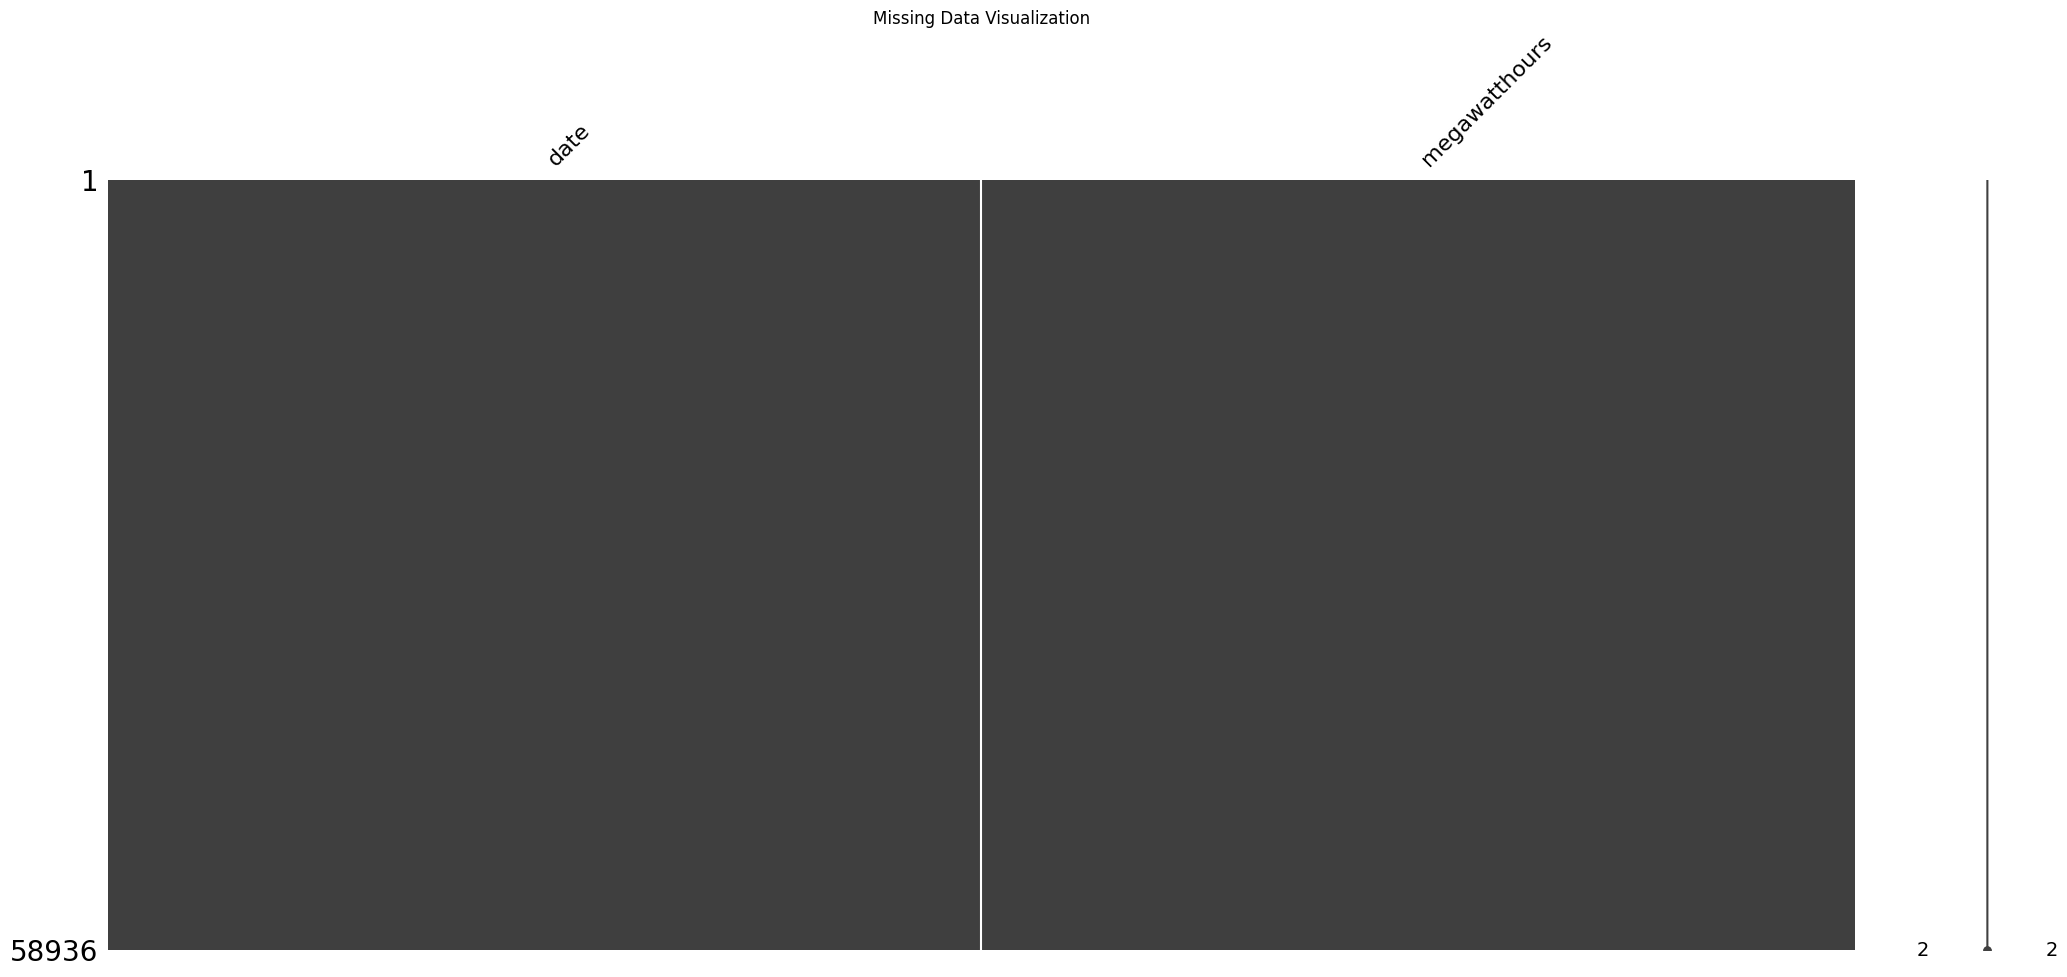

In [8]:
# -----------------------------------------------
# 2️⃣ Missing Values & Duplicates
# -----------------------------------------------
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

print("\n🔹 Duplicate Rows:", df.duplicated().sum())

# Missing data visualization
msno.matrix(df)
plt.title("Missing Data Visualization")
plt.show()

In [9]:
# -----------------------------------------------
# 3️⃣ Descriptive Statistics
# -----------------------------------------------
print("\n🔹 Summary Statistics:")
df.describe().T


🔹 Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
megawatthours,58936.0,455225.233032,74804.550019,162827.0,403987.0,443225.0,491449.0,719649.0


##### Data distribution can be checked using visualizations like histograms, density plots, and box plots to understand patterns, central tendency, and outliers

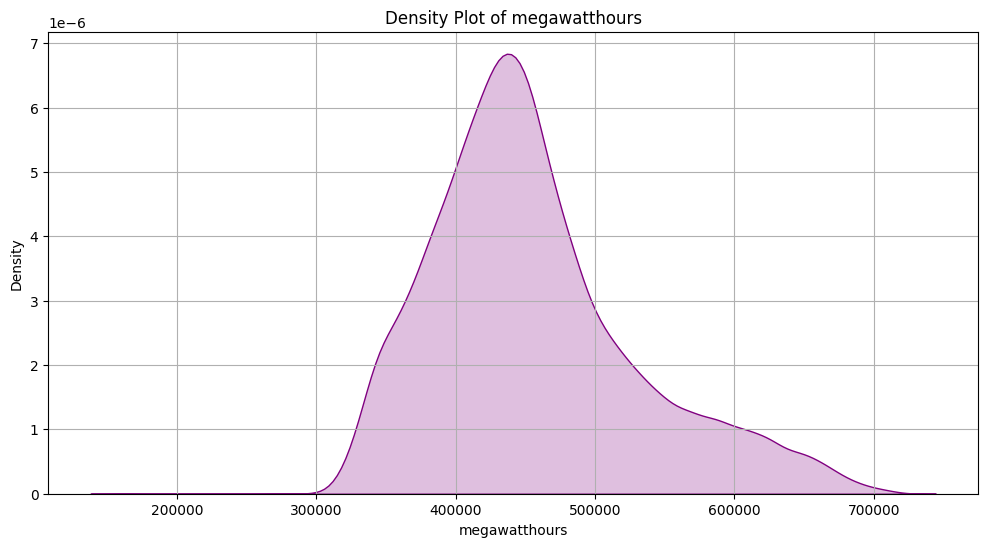

In [10]:
# Loop through each column and plot KDE
plt.figure(figsize=(12, 6))
sns.kdeplot(df['megawatthours'], shade=True, color='purple')
plt.title(f'Density Plot of megawatthours')
plt.xlabel('megawatthours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

### histograms

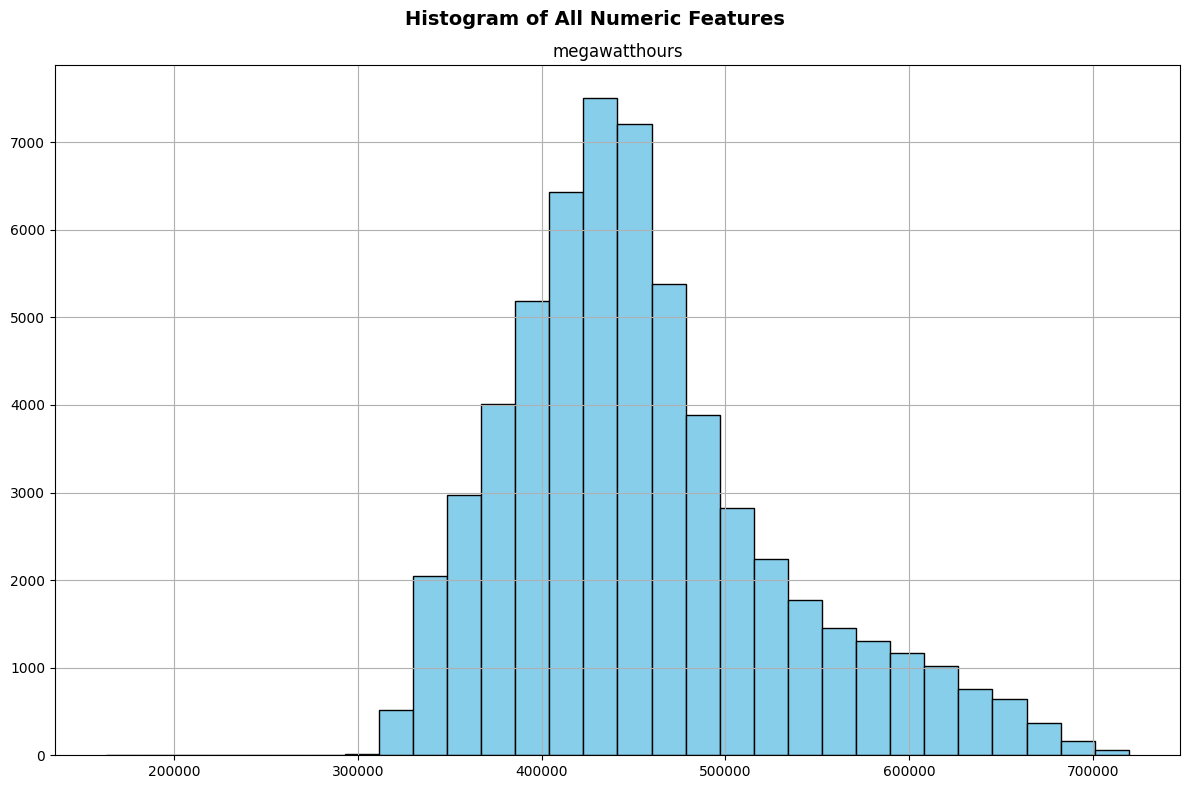

In [11]:
df.hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Histogram of All Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Core Data Check / Validation
print("🔍 Core Data Validation")
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("Missing Values:\n", df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Columns Names", df.columns)

🔍 Core Data Validation
Shape: (58936, 2)
Data Types:
 date             object
megawatthours     int64
dtype: object
Missing Values:
 date             0
megawatthours    0
dtype: int64
Duplicate Rows: 0
Columns Names Index(['date', 'megawatthours'], dtype='object')


#### to_datetime

In [13]:
# Ensure datetime is parsed
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M', errors='coerce')

In [14]:
df

,date,megawatthours
0,2015-07-01 05:00:00,162827
1,2015-07-01 06:00:00,335153
2,2015-07-01 07:00:00,333837
3,2015-07-01 08:00:00,398386
4,2015-07-01 09:00:00,388954
...,...,...
58931,2022-03-21 16:00:00,433344
58932,2022-03-21 17:00:00,429156
58933,2022-03-21 18:00:00,426496
58934,2022-03-21 19:00:00,423393


### Core time features

In [15]:
# ===== CORE TIME FEATURES =====
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear

In [16]:
df

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
0,2015-07-01 05:00:00,162827,5,2,1,182
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182
3,2015-07-01 08:00:00,398386,8,2,1,182
4,2015-07-01 09:00:00,388954,9,2,1,182
...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,16,0,21,80
58932,2022-03-21 17:00:00,429156,17,0,21,80
58933,2022-03-21 18:00:00,426496,18,0,21,80
58934,2022-03-21 19:00:00,423393,19,0,21,80


In [17]:
df.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year'],
      dtype='object')

#### EDA Analysis

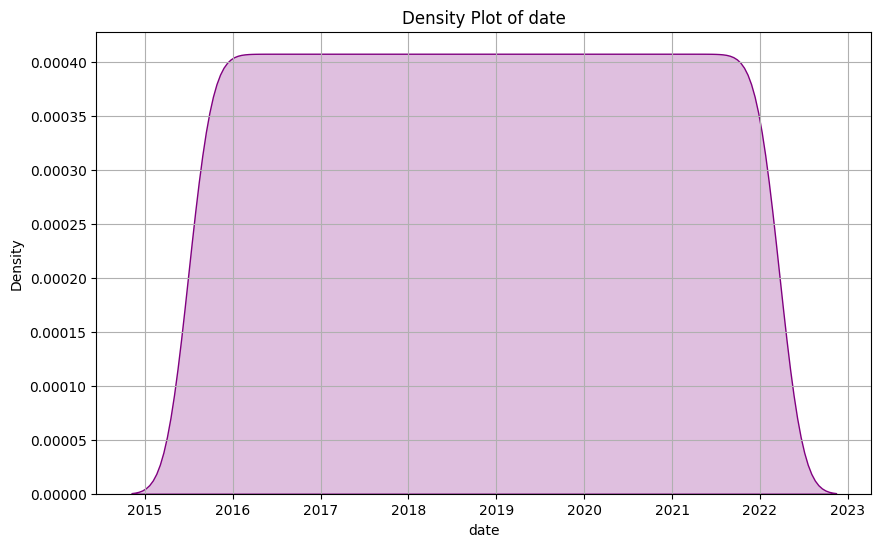

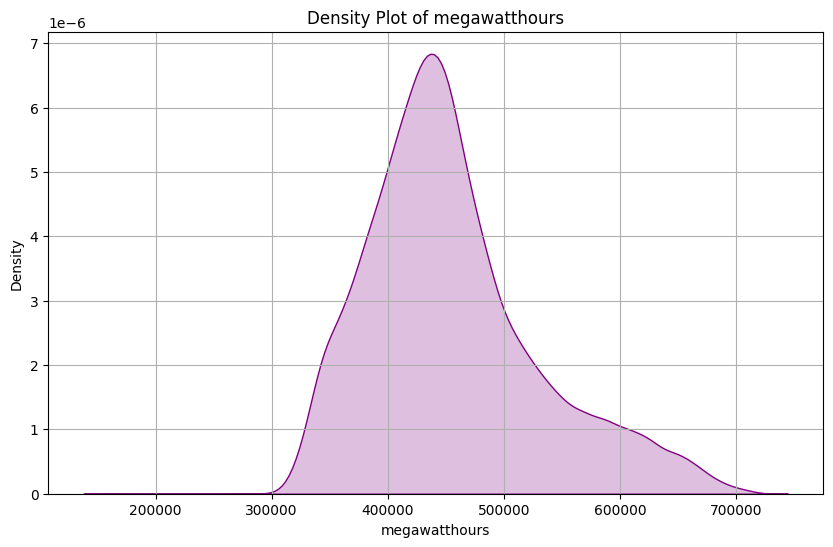

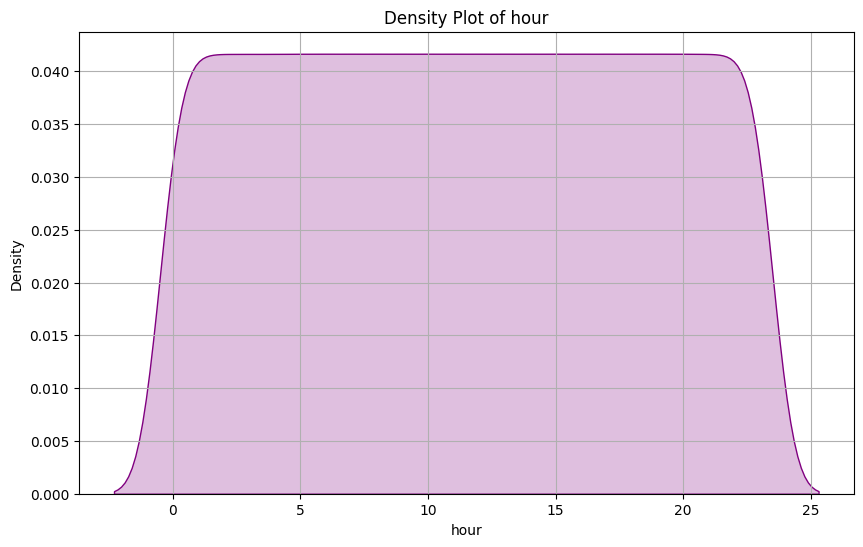

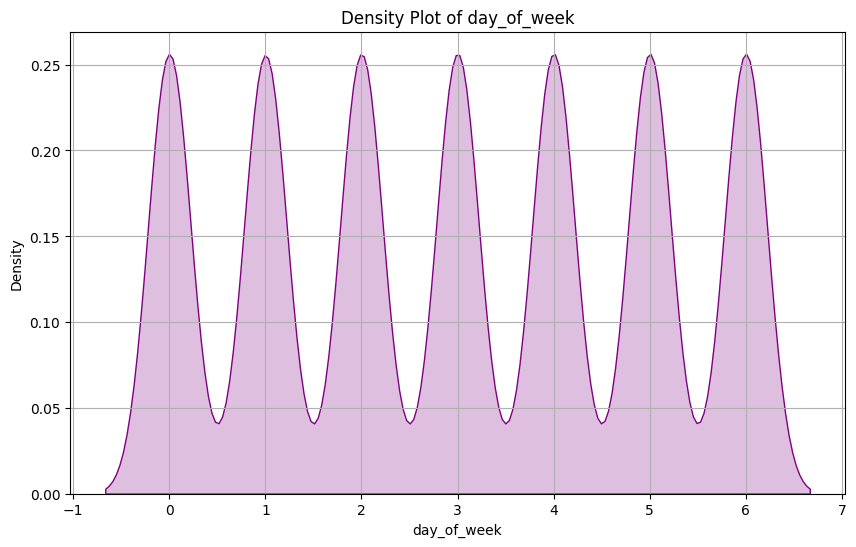

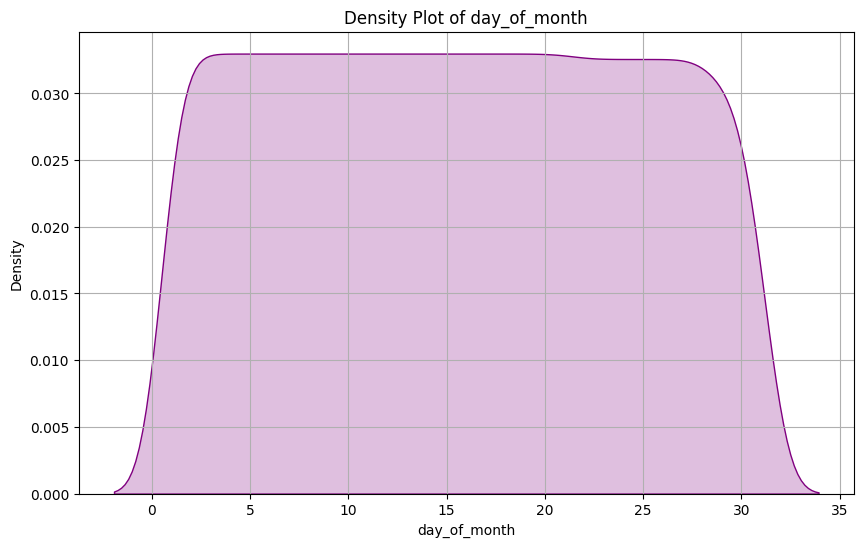

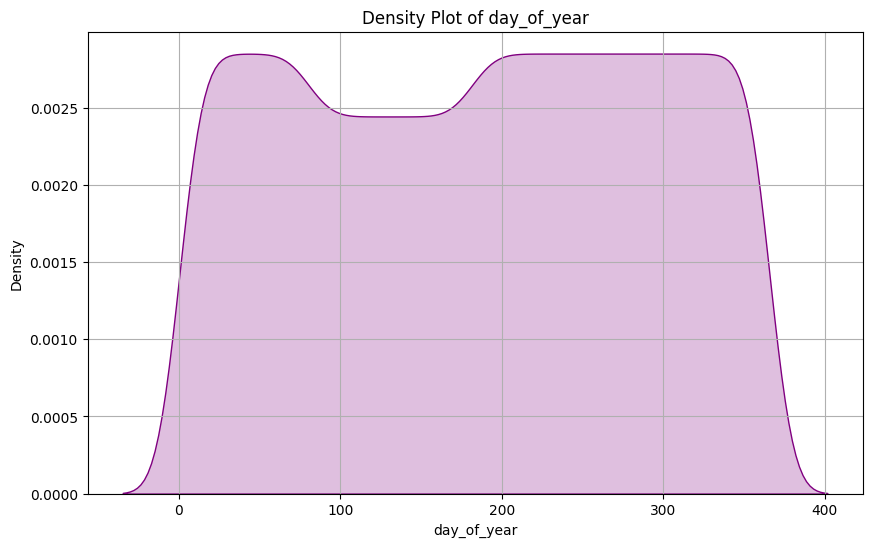

In [18]:


# List of columns to plot
columns_to_plot = ['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year']

# Loop through each column and plot KDE
for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df[col], shade=True, color='purple')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()

In [19]:
df

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
0,2015-07-01 05:00:00,162827,5,2,1,182
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182
3,2015-07-01 08:00:00,398386,8,2,1,182
4,2015-07-01 09:00:00,388954,9,2,1,182
...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,16,0,21,80
58932,2022-03-21 17:00:00,429156,17,0,21,80
58933,2022-03-21 18:00:00,426496,18,0,21,80
58934,2022-03-21 19:00:00,423393,19,0,21,80


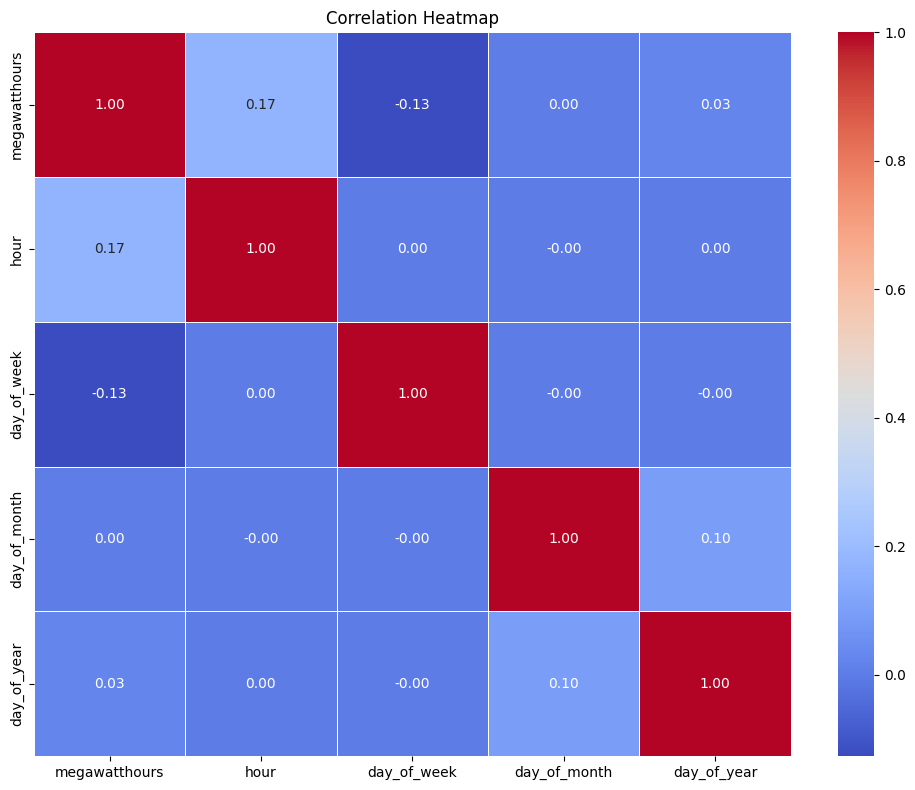

In [20]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

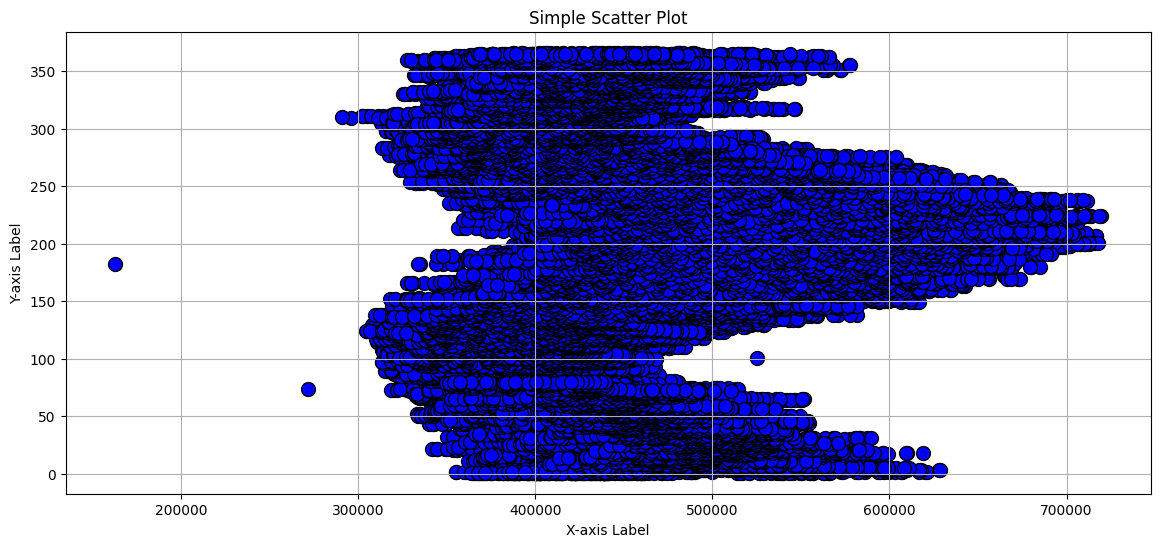

In [21]:
# Create scatter plot
plt.figure(figsize=(14, 6))  # Optional: enlarge canvas
plt.scatter(df['megawatthours'], df['day_of_year'], color='blue', marker='o', s=100, edgecolors='black')

# Add labels and title
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.title('Simple Scatter Plot')

# Show plot
plt.grid(True)
plt.show()

### Handling Outliers

Total data points: 58936
Outliers detected: 2242
Outlier values: [162827, 623522, 623216, 640279, 652235, 660073, 663547, 658633, 645083, 623910, 630055, 641020, 647899, 649879, 642669, 630109, 623298, 626393, 629297, 637152, 638748, 630664, 625014, 631301, 629503, 624323, 648418, 668585, 677361, 682785, 683238, 677092, 662509, 647155, 628903, 634703, 644857, 649742, 649781, 642770, 626221, 624897, 633022, 634930, 626969, 633831, 641648, 643880, 637585, 624131, 626291, 638350, 646847, 649685, 643248, 627383, 623908, 623575, 643959, 662301, 674114, 681558, 684292, 678654, 665324, 650340, 633854, 637340, 662723, 681189, 693716, 701269, 702262, 695909, 681178, 661219, 643534, 636701, 661416, 681173, 693055, 697737, 700172, 695396, 681609, 666056, 647241, 628494, 653672, 671434, 682163, 688288, 689487, 682378, 666540, 649856, 632088, 629510, 649445, 663258, 671328, 672025, 661287, 640359, 623459, 626464, 623052, 624706, 622905, 623169, 641028, 659147, 668028, 673043, 673106, 664723, 650394

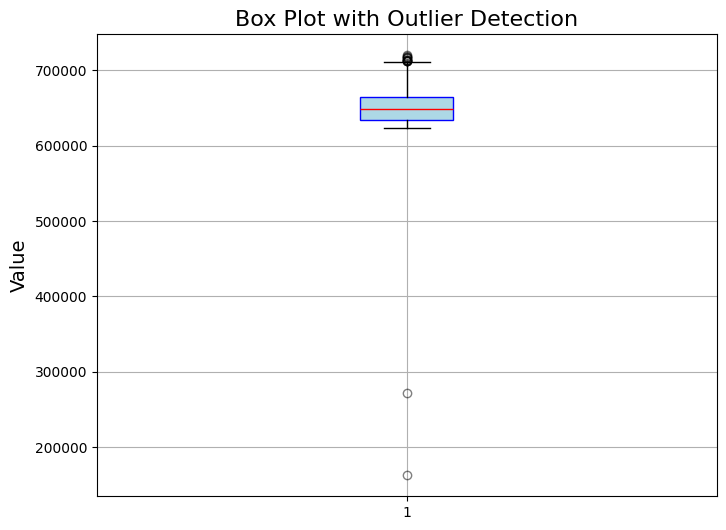

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Convert to NumPy array for calculations
data_array = np.array(df['megawatthours'])

# Calculate Q1, Q3, and IQR
Q1 = np.percentile(data_array, 25)
Q3 = np.percentile(data_array, 75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data_array[(data_array < lower_bound) | (data_array > upper_bound)]

# Print outlier info
print(f"Total data points: {len(data_array)}")
print(f"Outliers detected: {len(outliers)}")
print(f"Outlier values: {outliers.tolist()}")
print(f"Outlier values Len: {len(outliers)}")

# Create box plot
plt.figure(figsize=(8, 6))
plt.boxplot(outliers, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', color='orange', alpha=0.5))

# Add title and labels
plt.title('Box Plot with Outlier Detection', fontsize=16)
plt.ylabel('Value', fontsize=14)
plt.grid(True)
plt.show()

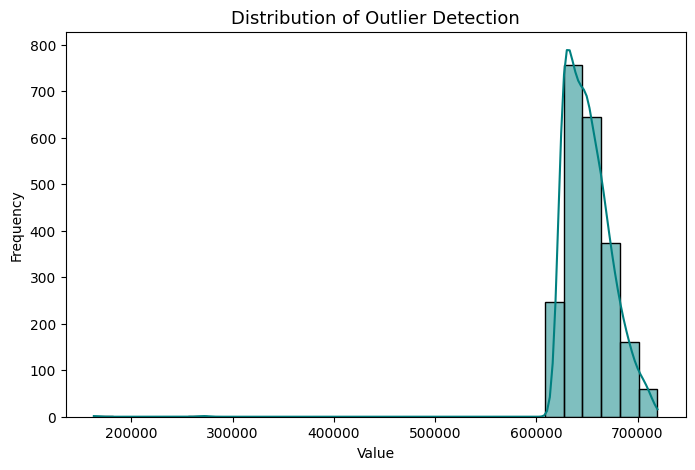

In [23]:
# -----------------------------------------------
# 2️⃣ Histogram for a Single Column
# -----------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(data = outliers, bins=30, kde=True, color='teal')
plt.title("Distribution of Outlier Detection", fontsize=13)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

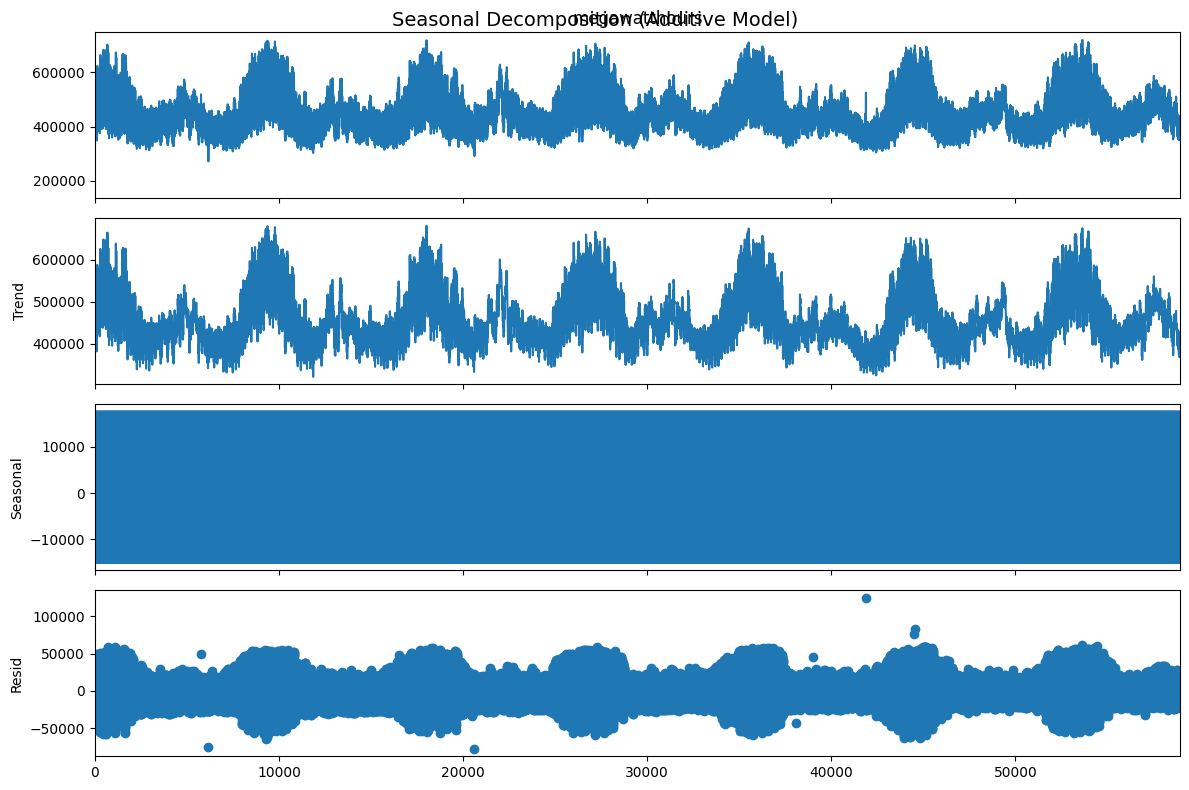

Trend Component:
 6     411951.541667
7     437086.333333
8     456590.958333
9     474573.541667
10    491012.791667
Name: trend, dtype: float64

Seasonal Component:
 0     1263.646457
1    -5912.377126
2   -11209.995804
3   -14485.472424
4   -15073.484280
Name: seasonal, dtype: float64

Residual Component:
 6     -2943.750066
7    -20408.525035
8    -28181.277207
9    -27763.451739
10   -15073.963879
Name: resid, dtype: float64


In [24]:
# ===========================================
# SEASONAL DECOMPOSITION (Trend, Seasonality, Residual)
# ===========================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Example: Load time series data (ensure it has a datetime index)
# Replace with your dataset
# df = pd.read_csv('your_timeseries.csv', parse_dates=['date'], index_col='date')

# Example: Select a numeric column to analyze
ts = df['megawatthours']   # Replace with your target column name

# Perform seasonal decomposition
# Model: 'additive' or 'multiplicative'
# Period: number of observations per cycle (e.g., 12 for monthly data, 7 for weekly)
result = seasonal_decompose(ts, model='additive', period=12)

# Plot the decomposition results
plt.rcParams.update({'figure.figsize': (12, 8)})
result.plot()
plt.suptitle('Seasonal Decomposition (Additive Model)', fontsize=14)
plt.show()

# Optional: Access individual components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Print summary statistics
print("Trend Component:\n", trend.dropna().head())
print("\nSeasonal Component:\n", seasonal.dropna().head())
print("\nResidual Component:\n", residual.dropna().head())



In [25]:
df.shape

(58936, 6)

In [26]:
df.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year'],
      dtype='object')

Manual Outlier Cutoffs → Lower: 300000, Upper: 650000
Original Shape: (58936, 6)
Filtered Shape: (57882, 6)


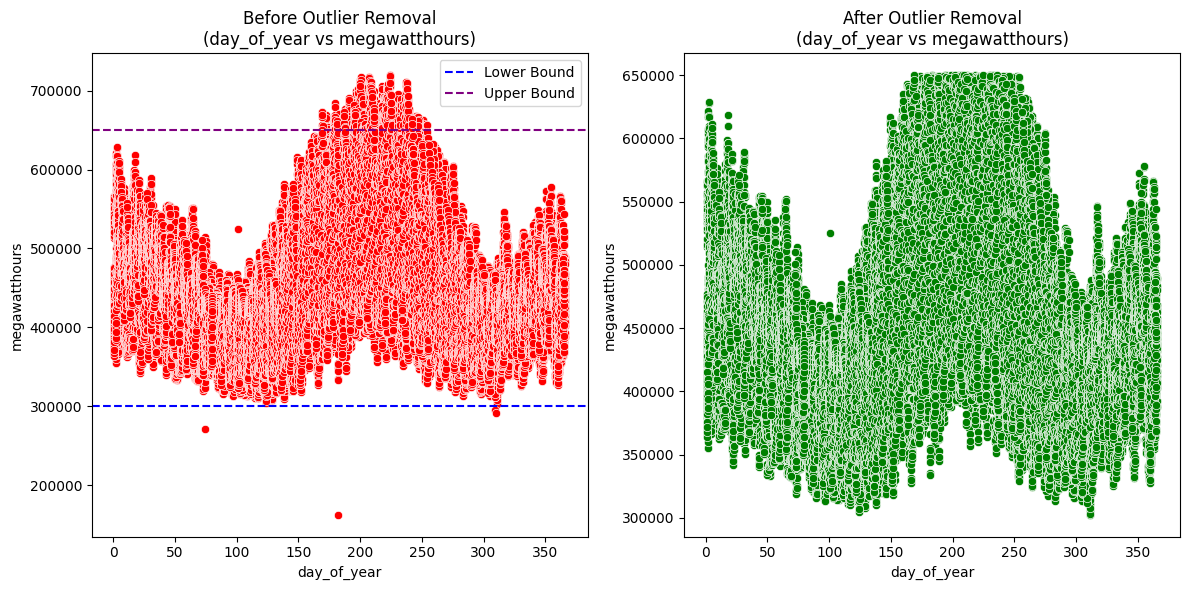

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Define your columns ---
target_col = 'megawatthours'        # 🔁 your target column
X_feature = 'day_of_year'    # 🔁 your x-axis feature (e.g., 'humidity', 'day', etc.)

# --- Step 2: Define manual cutoff values ---
lowerbound = 300000     # 👈 set your lower limit
upperbound = 650000    # 👈 set your upper limit

# --- Step 3: Apply filtering based on manual cutoffs ---
new_df = df[(df[target_col] >= lowerbound) & (df[target_col] <= upperbound)]

print(f"Manual Outlier Cutoffs → Lower: {lowerbound}, Upper: {upperbound}")
print("Original Shape:", df.shape)
print("Filtered Shape:", new_df.shape)

# --- Step 4: Scatter Plot Visualization ---
plt.figure(figsize=(12, 6))

# Before outlier removal
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x=X_feature, y=target_col, color='red', alpha=1)
plt.axhline(lowerbound, color='blue', linestyle='--', label='Lower Bound')
plt.axhline(upperbound, color='purple', linestyle='--', label='Upper Bound')
plt.legend()
plt.title(f"Before Outlier Removal\n({X_feature} vs {target_col})")

# After outlier removal
plt.subplot(1, 2, 2)
sns.scatterplot(data=new_df, x=X_feature, y=target_col, color='green', alpha=1)
plt.title(f"After Outlier Removal\n({X_feature} vs {target_col})")

plt.tight_layout()
plt.show()



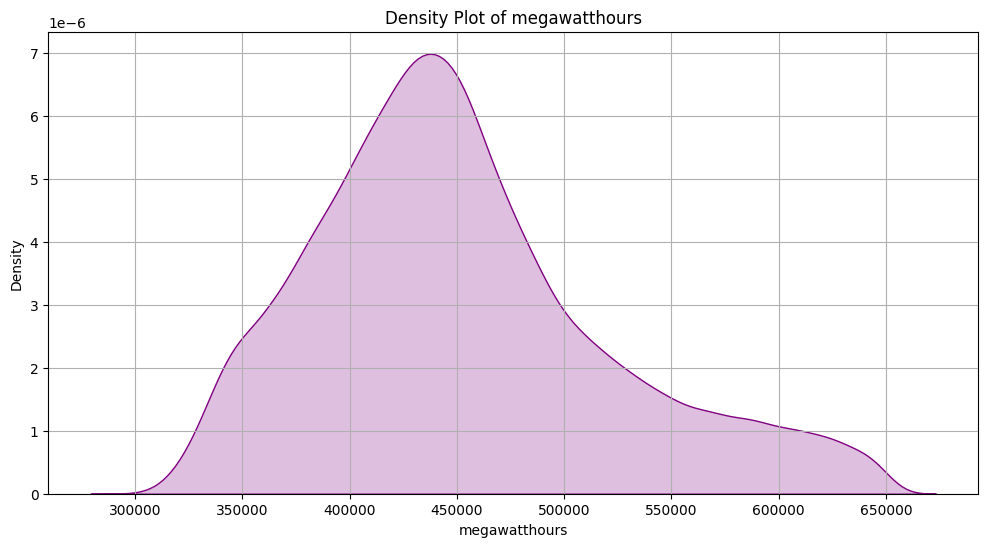

In [28]:
# Loop through each column and plot KDE
plt.figure(figsize=(12, 6))
sns.kdeplot(new_df['megawatthours'], shade=True, color='purple')
plt.title(f'Density Plot of megawatthours')
plt.xlabel('megawatthours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [29]:
import pandas as pd


# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Call the function
df_clean = remove_outliers_iqr(df, 'megawatthours')


In [71]:
df_clean.columns

Index(['megawatthours', 'hour_sin', 'hour_cos', 'dayofweek_sin',
       'dayofweek_cos', 'dayofmonth_sin', 'dayofmonth_cos', 'dayofyear_sin',
       'dayofyear_cos'],
      dtype='object')

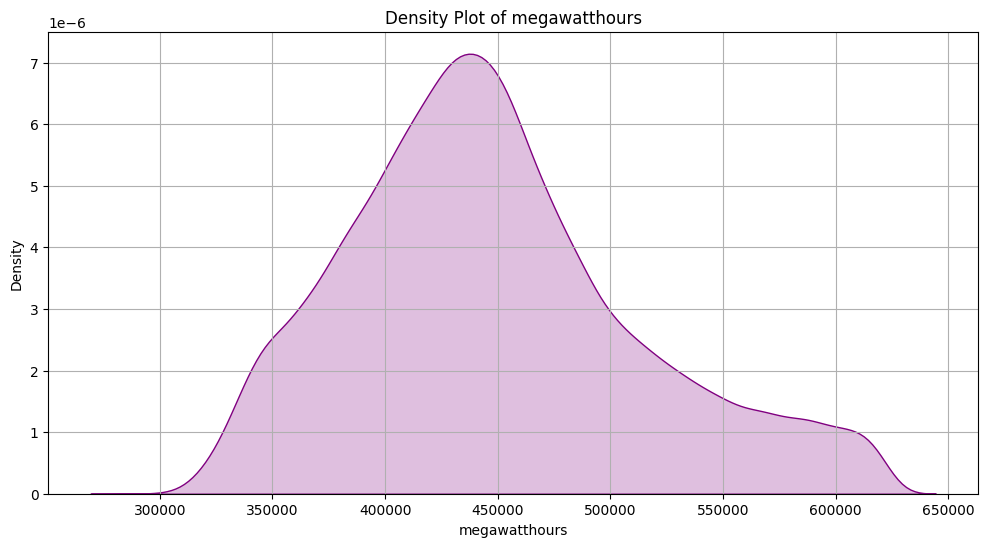

In [31]:
# Loop through each column and plot KDE
plt.figure(figsize=(12, 6))
sns.kdeplot(df_clean['megawatthours'], shade=True, color='purple')
plt.title(f'Density Plot of megawatthours')
plt.xlabel('megawatthours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [32]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
date,56694,2018-11-11 16:23:47.452640512,2015-07-01 06:00:00,2017-03-08 09:15:00,2018-11-13 21:30:00,2020-07-14 10:45:00,2022-03-21 20:00:00,NaN
megawatthours,56694.0,447474.846721,291060.0,402234.0,440355.5,483636.5,622620.0,64910.735147
hour,56694.0,11.313649,0.0,5.0,11.0,17.0,23.0,6.780731
day_of_week,56694.0,3.025523,0.0,1.0,3.0,5.0,6.0,2.008721
day_of_month,56694.0,15.644636,1.0,8.0,16.0,23.0,31.0,8.800998
day_of_year,56694.0,184.29467,1.0,86.0,185.0,281.0,366.0,108.782196


In [33]:
df_clean.head(2)

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year
1,2015-07-01 06:00:00,335153,6,2,1,182
2,2015-07-01 07:00:00,333837,7,2,1,182


## variance threshold

Feature Variances:
 megawatthours    4.213404e+09
hour             4.597832e+01
day_of_week      4.034961e+00
day_of_month     7.745756e+01
day_of_year      1.183357e+04
dtype: float64

Selected Features (Variance > threshold):
['megawatthours', 'hour', 'day_of_week', 'day_of_month', 'day_of_year']

Original shape: (56694, 5)
Reduced shape: (56694, 5)


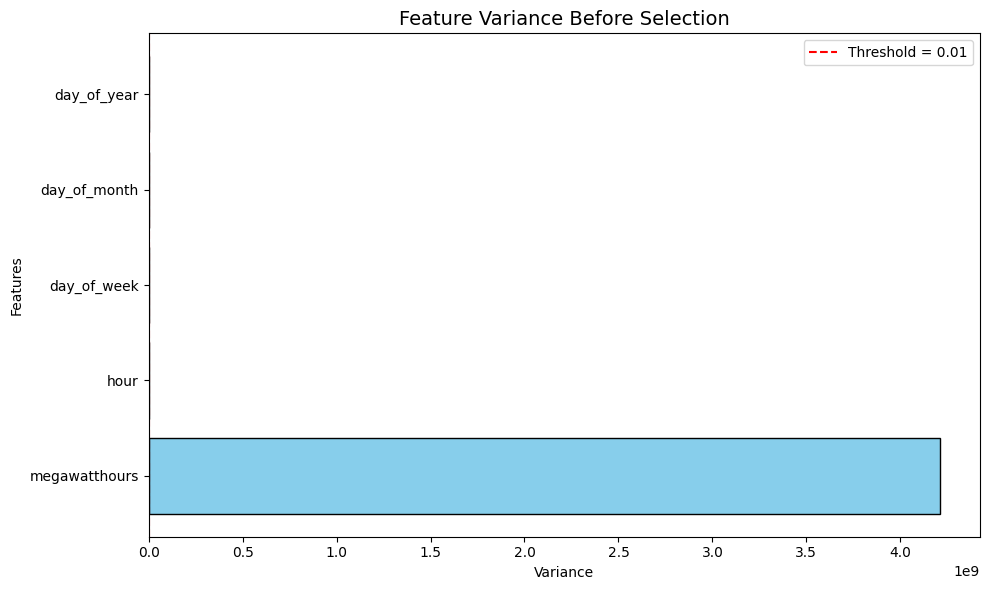

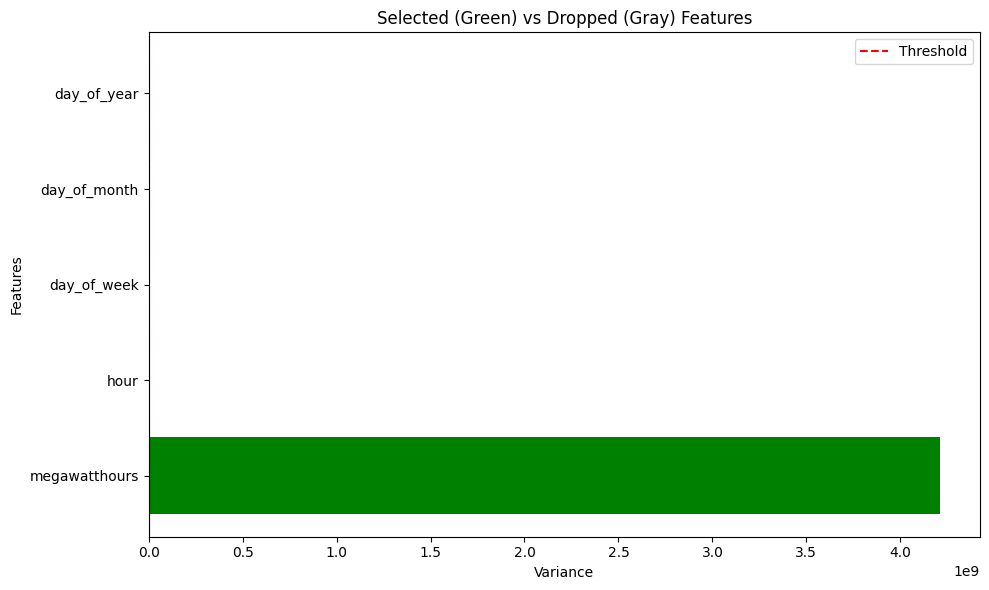

In [34]:
# ============================================
# VARIANCE THRESHOLD FEATURE SELECTION
# ============================================

# 0.0	Removes features with zero variance (constant values)	Basic cleanup
# >0.01	Removes features with very low variance	Useful for high-dimensional data
# 0.1–0.2	Aggressive filtering	Use with caution; may remove informative features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# ----- STEP 1: Load or prepare clean dataset -----
# Assume df is your clean DataFrame
# Example: df = pd.read_csv('data.csv')

# Remove non-numeric columns if present
dfnumeric = df_clean.select_dtypes(include=[np.number])

# ----- STEP 2: Check variance of all features -----
feature_variances = dfnumeric.var()
print("Feature Variances:\n", feature_variances)

# ----- STEP 3: Apply VarianceThreshold -----
threshold = 0.01  # you can adjust this value (e.g., 0.0, 0.01, 0.02)
selector = VarianceThreshold(threshold=threshold)
X_selected = selector.fit_transform(dfnumeric)

# Get selected feature names
selected_features = dfnumeric.columns[selector.get_support()]
print("\nSelected Features (Variance > threshold):")
print(selected_features.tolist())

# ----- STEP 4: Create a new filtered DataFrame -----
df_selected = dfnumeric[selected_features]
print(f"\nOriginal shape: {dfnumeric.shape}")
print(f"Reduced shape: {df_selected.shape}")

# ----- STEP 5: Visualization - Variance Comparison -----
plt.figure(figsize=(10, 6))
plt.barh(dfnumeric.columns, feature_variances, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold}')
plt.title('Feature Variance Before Selection', fontsize=14)
plt.xlabel('Variance')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()

# ----- STEP 6: Visualization - Selected vs Dropped -----
plt.figure(figsize=(10, 6))
selected_mask = selector.get_support()
colors = ['green' if selected else 'gray' for selected in selected_mask]
plt.barh(dfnumeric.columns, feature_variances, color=colors)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.title('Selected (Green) vs Dropped (Gray) Features')
plt.xlabel('Variance')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()



## Variance Inflation Factor (VIF)

In [35]:
df_clean.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year'],
      dtype='object')

In [70]:
df_clean

,megawatthours,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
date,,,,,,,,,
2015-07-01 06:00:00,335153,1.000000,6.123234e-17,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 07:00:00,333837,0.965926,-2.588190e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 08:00:00,398386,0.866025,-5.000000e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 09:00:00,388954,0.707107,-7.071068e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 10:00:00,392487,0.500000,-8.660254e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
...,...,...,...,...,...,...,...,...,...
2022-03-21 16:00:00,433344,-0.866025,-5.000000e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
2022-03-21 17:00:00,429156,-0.965926,-2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
2022-03-21 18:00:00,426496,-1.000000,-1.836970e-16,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315



✅ Features selected for VIF calculation (excluding target 'megawatthours'):
['hour', 'day_of_week', 'day_of_month', 'day_of_year']

📊 Variance Inflation Factor (VIF) Results:

        Feature        VIF
0         const  11.509541
1   day_of_year   1.009803
2  day_of_month   1.009758
3          hour   1.000231
4   day_of_week   1.000194

⚠️ Features with high multicollinearity (VIF > 10):
  Feature        VIF
0   const  11.509541


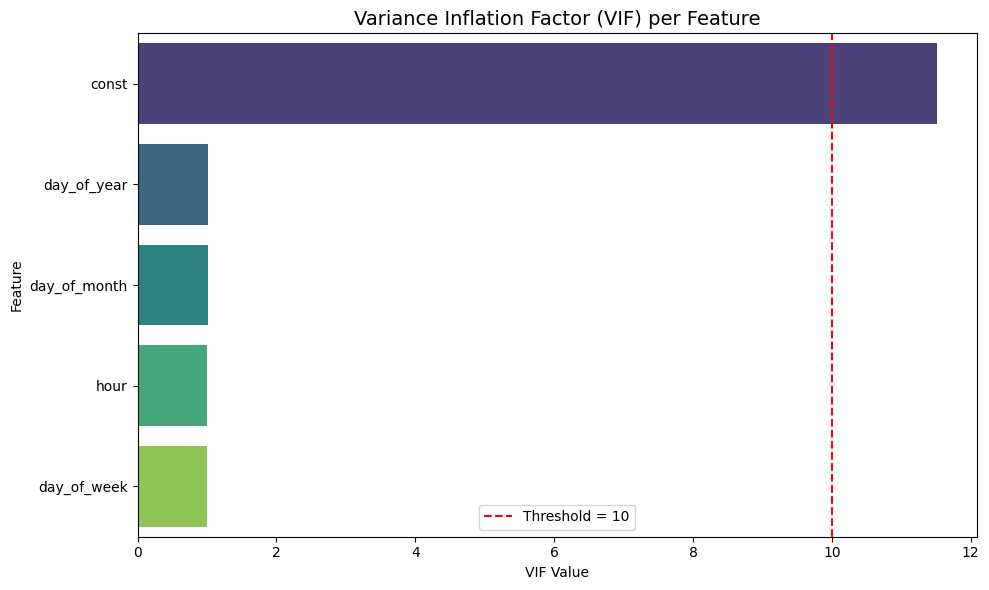

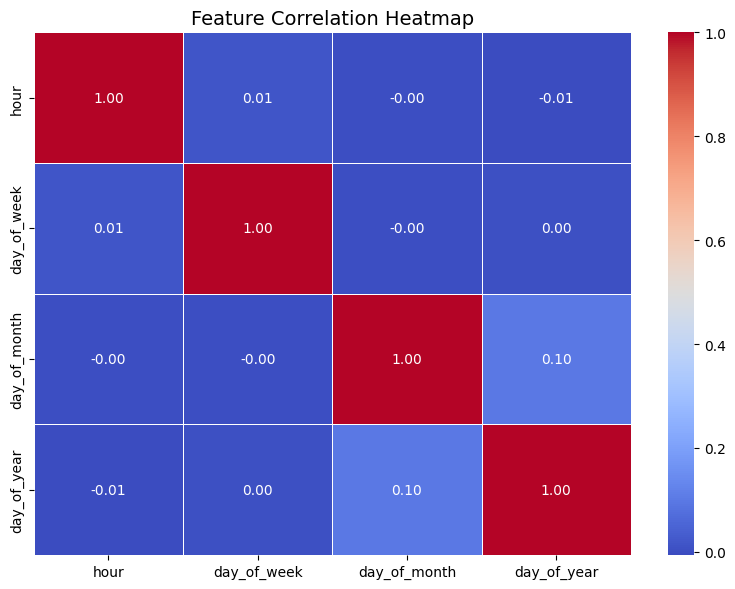

In [36]:
# ============================================
# MULTICOLLINEARITY CHECK USING VIF (V & I Separated)
# ============================================
# Guide:
#  VIF < 5   → Low to moderate multicollinearity (acceptable)
#  5 ≤ VIF ≤ 10 → High multicollinearity (monitor carefully)
#  VIF > 10  → Very high multicollinearity (consider feature removal)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant  # ✅ Added for VIF stability

# ----- STEP 1: Prepare Data -----
target_column = 'megawatthours'  # 🔁 Change this to your actual target column
df_model = df_clean.copy()

# Separate V (features) and I (target)
V = df_model.drop(columns=[target_column], errors='ignore')
I = df_model[target_column] if target_column in df_model.columns else None

# Ensure V has only numeric features and no missing values
V = V.select_dtypes(include=[np.number]).dropna()

# Add constant to stabilize VIF calculation
V_const = add_constant(V)

print(f"\n✅ Features selected for VIF calculation (excluding target '{target_column}'):")
print(list(V.columns))

# ----- STEP 2: Compute VIF -----
vif_data = pd.DataFrame()
vif_data["Feature"] = V_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(V_const.values, i)
    for i in range(V_const.shape[1])
]

# ----- STEP 3: Sort by VIF -----
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print("\n📊 Variance Inflation Factor (VIF) Results:\n")
print(vif_data)

# ----- STEP 4: Identify high-VIF features -----
high_vif = vif_data[vif_data["VIF"] > 10]
if not high_vif.empty:
    print("\n⚠️ Features with high multicollinearity (VIF > 10):")
    print(high_vif)
else:
    print("\n✅ No features with critical multicollinearity detected (VIF ≤ 10).")

# ----- STEP 5: Visualization — VIF Bar Chart -----
plt.figure(figsize=(10, 6))
sns.barplot(x="VIF", y="Feature", data=vif_data, palette="viridis")
plt.axvline(10, color='red', linestyle='--', label='Threshold = 10')
plt.title("Variance Inflation Factor (VIF) per Feature", fontsize=14)
plt.xlabel("VIF Value")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

# ----- STEP 6: Visualization — Correlation Heatmap -----
plt.figure(figsize=(8, 6))
sns.heatmap(V.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


## Statistical Tests ANOVA

=== ANOVA F-Test Feature Scores ===
        Feature   F_Score   P_Value
0          hour  1.055707  0.001719
1   day_of_week  1.040315  0.016350
2  day_of_month  0.991128  0.688033
3   day_of_year  0.930974  0.999958


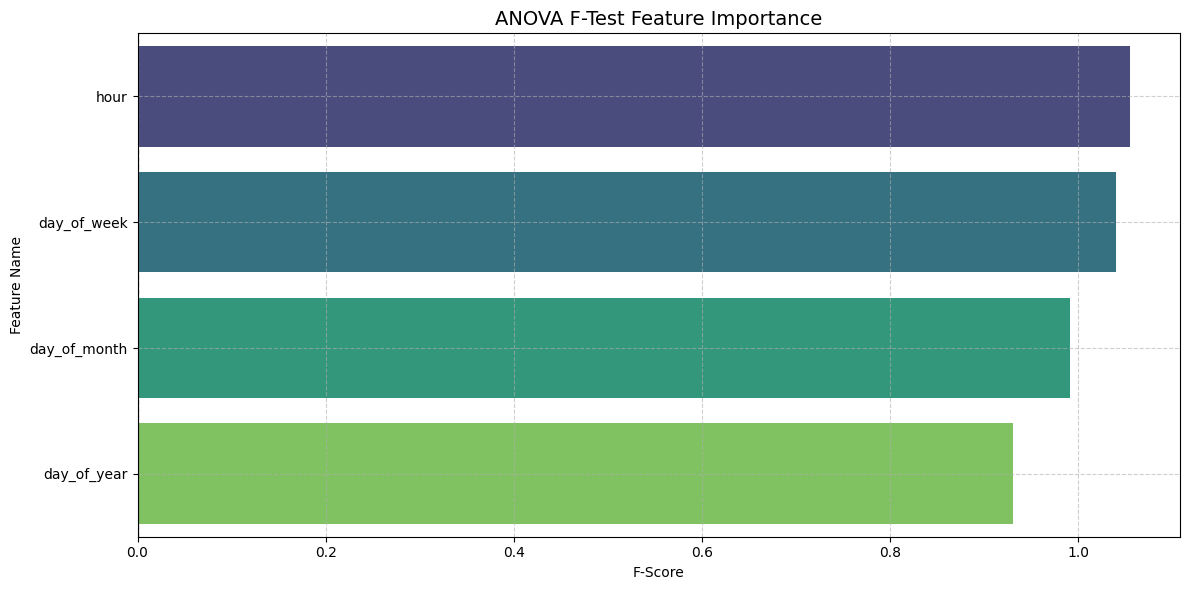


✅ Significant Features (p < 0.05):
['hour', 'day_of_week']


In [37]:
# ==============================================
# ANOVA F-Test Feature Selection with Visualization
# ==============================================
# Select features with:
# - High F-score
# - Low p-value (typically < 0.05)

import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# STEP 1: Load Data
# -------------------------------
# Separate features and target
target_column = "megawatthours"  # Replace with your actual target column
anova_X = df_clean.drop(columns=[target_column], errors='ignore')
anova_y = df_clean[target_column]

# Keep only numeric features
X_numeric = anova_X.select_dtypes(include=[np.number]).dropna()

# -------------------------------
# STEP 2: Apply ANOVA F-Test
# -------------------------------
selector = SelectKBest(score_func=f_classif, k='all')  # use 'all' to get all scores
X_new = selector.fit_transform(X_numeric, anova_y)

# Get feature scores and p-values
anova_scores = selector.scores_
anova_pvalues = selector.pvalues_

# Combine results into a DataFrame
anova_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F_Score': anova_scores,
    'P_Value': anova_pvalues
}).sort_values(by='F_Score', ascending=False).reset_index(drop=True)

print("=== ANOVA F-Test Feature Scores ===")
print(anova_df)

# -------------------------------
# STEP 3: Visualization
# -------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(x='F_Score', y='Feature', data=anova_df, palette='viridis')
plt.title("ANOVA F-Test Feature Importance", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Feature Name")
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -------------------------------
# STEP 4: Filter Important Features (Optional)
# -------------------------------
significant_features = anova_df[anova_df['P_Value'] < 0.05]['Feature']
print("\n✅ Significant Features (p < 0.05):")
print(significant_features.tolist())



## Feature engineering & Feature selection

In [38]:
# ===== CYCLIC (PERIODIC) FEATURES =====
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean['hour'] / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean['hour'] / 24)
df_clean['dayofweek_sin'] = np.sin(2 * np.pi * df_clean['day_of_week'] / 7)
df_clean['dayofweek_cos'] = np.cos(2 * np.pi * df_clean['day_of_week'] / 7)
df_clean['dayofmonth_sin'] = np.sin(2 * np.pi * (df_clean['day_of_month'] - 1) / 31)
df_clean['dayofmonth_cos'] = np.cos(2 * np.pi * (df_clean['day_of_month'] - 1) / 31)
df_clean['dayofyear_sin'] = np.sin(2 * np.pi * (df_clean['day_of_year'] - 1) / 365)
df_clean['dayofyear_cos'] = np.cos(2 * np.pi * (df_clean['day_of_year'] - 1) / 365)


In [39]:
df_clean.head(2)

,date,megawatthours,hour,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
1,2015-07-01 06:00:00,335153,6,2,1,182,1.000000,6.123234e-17,0.974928,-0.222521,0.0,1.0,0.025818,-0.999667
2,2015-07-01 07:00:00,333837,7,2,1,182,0.965926,-2.588190e-01,0.974928,-0.222521,0.0,1.0,0.025818,-0.999667


## corrmatrix 


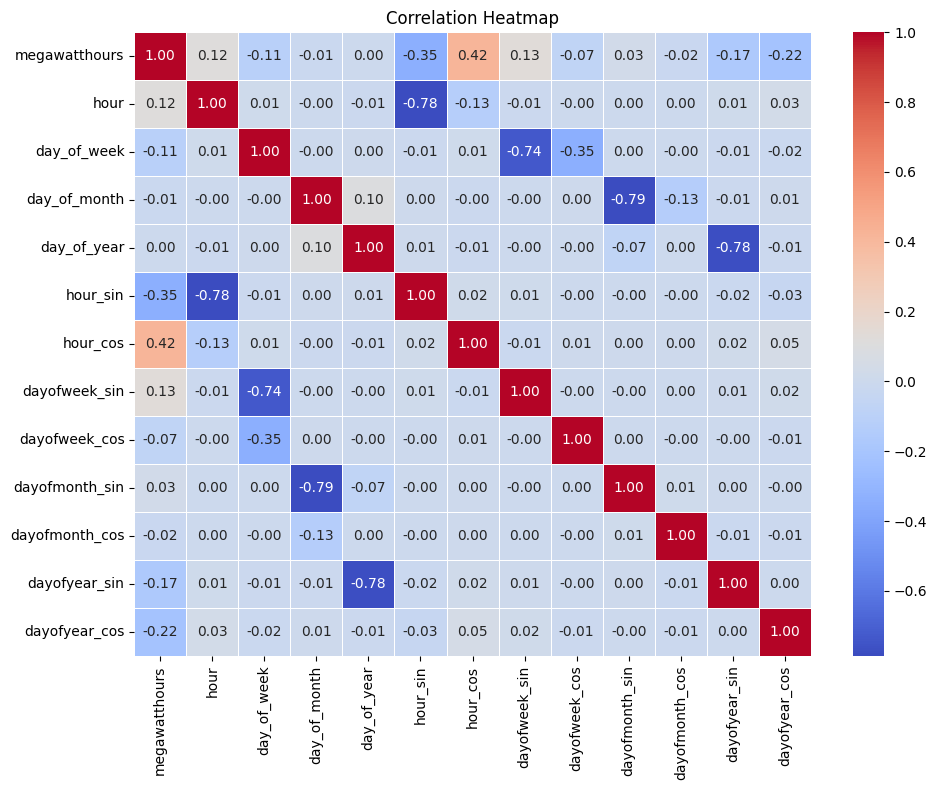

In [40]:
# Compute correlation matrix
corrmatrix01 = df_clean.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corrmatrix01, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [41]:
df_clean.columns

Index(['date', 'megawatthours', 'hour', 'day_of_week', 'day_of_month',
       'day_of_year', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',
       'dayofmonth_sin', 'dayofmonth_cos', 'dayofyear_sin', 'dayofyear_cos'],
      dtype='object')

In [42]:
df_clean.drop(columns=['hour', 'day_of_week', 'day_of_month','day_of_year'], axis=1, inplace=True)

In [43]:
df_clean

,date,megawatthours,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
1,2015-07-01 06:00:00,335153,1.000000,6.123234e-17,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2,2015-07-01 07:00:00,333837,0.965926,-2.588190e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
3,2015-07-01 08:00:00,398386,0.866025,-5.000000e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
4,2015-07-01 09:00:00,388954,0.707107,-7.071068e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
5,2015-07-01 10:00:00,392487,0.500000,-8.660254e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
...,...,...,...,...,...,...,...,...,...,...
58931,2022-03-21 16:00:00,433344,-0.866025,-5.000000e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58932,2022-03-21 17:00:00,429156,-0.965926,-2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58933,2022-03-21 18:00:00,426496,-1.000000,-1.836970e-16,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
58934,2022-03-21 19:00:00,423393,-0.965926,2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315


In [44]:
df_clean.set_index('date', inplace=True)

In [45]:
df_clean

,megawatthours,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
date,,,,,,,,,
2015-07-01 06:00:00,335153,1.000000,6.123234e-17,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 07:00:00,333837,0.965926,-2.588190e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 08:00:00,398386,0.866025,-5.000000e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 09:00:00,388954,0.707107,-7.071068e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
2015-07-01 10:00:00,392487,0.500000,-8.660254e-01,0.974928,-0.222521,0.000000,1.000000,0.025818,-0.999667
...,...,...,...,...,...,...,...,...,...
2022-03-21 16:00:00,433344,-0.866025,-5.000000e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
2022-03-21 17:00:00,429156,-0.965926,-2.588190e-01,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315
2022-03-21 18:00:00,426496,-1.000000,-1.836970e-16,0.000000,1.000000,-0.790776,-0.612106,0.977848,0.209315


 ## Model Selection & Cross-Validation & Train-Test Split

In [46]:
# ============================================
# IMPORTS
# ============================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ============================================
# STEP 1: DEFINE FEATURES AND TARGET
# ============================================
# Assuming df_clean is already loaded and cleaned
X = df_clean.drop(columns=['megawatthours'])  # Independent variables
y = df_clean['megawatthours']                 # Target variable

# ============================================
# STEP 2: TRAIN–TEST SPLIT (80-20)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# ============================================
# STEP 3: SCALE ONLY THE TARGET VARIABLE (y)
# ============================================

# Initialize MinMaxScaler for target only
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit-transform on training target and transform on test target
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Keep X as-is (no scaling required)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

print("✅ Target scaling completed successfully (X not scaled).")

# ============================================
# STEP 4: CREATE SEQUENCES AFTER SCALING
# ============================================
def create_sequences(X, y, seq_length=7):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X.iloc[i:i+seq_length].values)
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 7
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, seq_length)

print(f"Training Sequence Shape: {X_train_seq.shape}")
print(f"Testing Sequence Shape:  {X_test_seq.shape}")

X_train: (45355, 8), X_test: (11339, 8)
✅ Target scaling completed successfully (X not scaled).
Training Sequence Shape: (45348, 7, 8)
Testing Sequence Shape:  (11332, 7, 8)


 ## Model Traning

In [47]:
# ============================================
# STEP 5: BUILD OPTIMIZED LSTM MODEL
# ============================================
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(seq_length, X_train_seq.shape[2])),
    Dropout(0.3),

    LSTM(64, return_sequences=True),
    Dropout(0.3),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# ============================================
# STEP 6: CALLBACKS
# ============================================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

# ============================================
# STEP 7: MODEL TRAINING
# ============================================
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n✅ Training completed at epoch {len(history.history['loss'])}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 128)         │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,513 (517.63 KB)

 Trainable params: 132,513 (517.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0141 - mae: 0.0843 - val_loss: 0.0064 - val_mae: 0.0610 - learning_rate: 0.0010
Epoch 2/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0073 - mae: 0.0653 - val_loss: 0.0060 - val_mae: 0.0582 - learning_rate: 0.0010
Epoch 3/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0066 - mae: 0.0620 - val_loss: 0.0081 - val_mae: 0.0658 - learning_rate: 0.0010
Epoch 4/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0062 - mae: 0.0601 - val_loss: 0.0070 - val_mae: 0.0634 - learning_rate: 0.0010
Epoch 5/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0060 - mae: 0.0590 - val_loss: 0.0075 - val_mae: 0.0642 - learning_rate: 0.0010
Epoch 6/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0059 - mae: 0.0582 - val_loss: 0.0069 - val_mae: 0.0623 - learning_rate: 0.0010
Epoch 7/100
709/709 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0057 - mae: 0.0573 - val_loss: 0.0066 - val_mae: 0.0613 - learning_rate: 0.

## Model Evaluation & Predictions


📊 TRAINING SET Metrics:
  MSE:  650578568.5794
  RMSE: 25506.4417
  MAE:  19497.0249
  R²:   0.8513
  MAPE: 4.40%

📊 TEST SET Metrics:
  MSE:  655304643.2210
  RMSE: 25598.9188
  MAE:  19304.2448
  R²:   0.8157
  MAPE: 4.24%
{'MSE': 650578568.57937, 'RMSE': np.float64(25506.441707524984), 'MAE': 19497.02488946591, 'R2': 0.8512936403807074, 'MAPE': np.float64(4.403617429176398)}
{'MSE': 655304643.2209901, 'RMSE': np.float64(25598.91879007764), 'MAE': 19304.244848658665, 'R2': 0.8156663658066604, 'MAPE': np.float64(4.2405669676548445)}


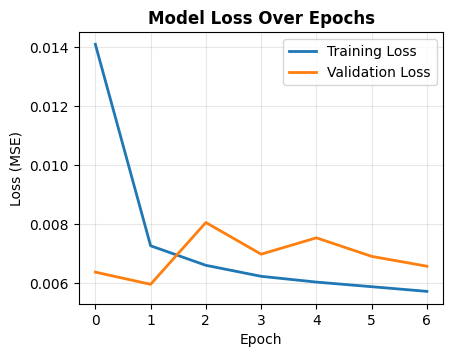

In [48]:
# ============================================
# STEP 7: MAKE PREDICTIONS
# ============================================
y_train_pred_scaled = model.predict(X_train_seq, verbose=0)
y_test_pred_scaled = model.predict(X_test_seq, verbose=0)

# Inverse transform to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled).flatten()
y_train_actual = scaler_y.inverse_transform(y_train_seq).flatten()
y_test_actual = scaler_y.inverse_transform(y_test_seq).flatten()

# ============================================
# STEP 8: EVALUATE MODEL PERFORMANCE
# ============================================
def evaluate_model(y_true, y_pred, set_name=""):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n📊 {set_name} Metrics:")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train_actual, y_train_pred, "TRAINING SET")
test_metrics = evaluate_model(y_test_actual, y_test_pred, "TEST SET")
print(train_metrics)
print(test_metrics)

# 5. VISUALIZATIONS - MODEL PERFORMANCE

fig = plt.figure(figsize=(16, 12))

# 1. Training History - Loss
ax1 = plt.subplot(3, 3, 1)
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Model Loss Over Epochs', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

In [49]:
# ============================================
# STEP 10: RESIDUAL DIAGNOSTICS
# ============================================
print("\n🔍 STEP 10: RESIDUAL DIAGNOSTICS")
print("-" * 70)

residuals_test = y_test_actual - y_test_pred
stat, p_val = stats.normaltest(residuals_test)
print(f"Residuals Normality Test: p-value = {p_val:.6f}")
print(f"  Result: {'Normal' if p_val > 0.05 else 'Non-normal'} residuals")


🔍 STEP 10: RESIDUAL DIAGNOSTICS
----------------------------------------------------------------------
Residuals Normality Test: p-value = 0.000000
  Result: Non-normal residuals



📊 STEP 11: GENERATING VISUALIZATIONS
----------------------------------------------------------------------
✅ Comprehensive visualization saved: 'model_performance_analysis.png'


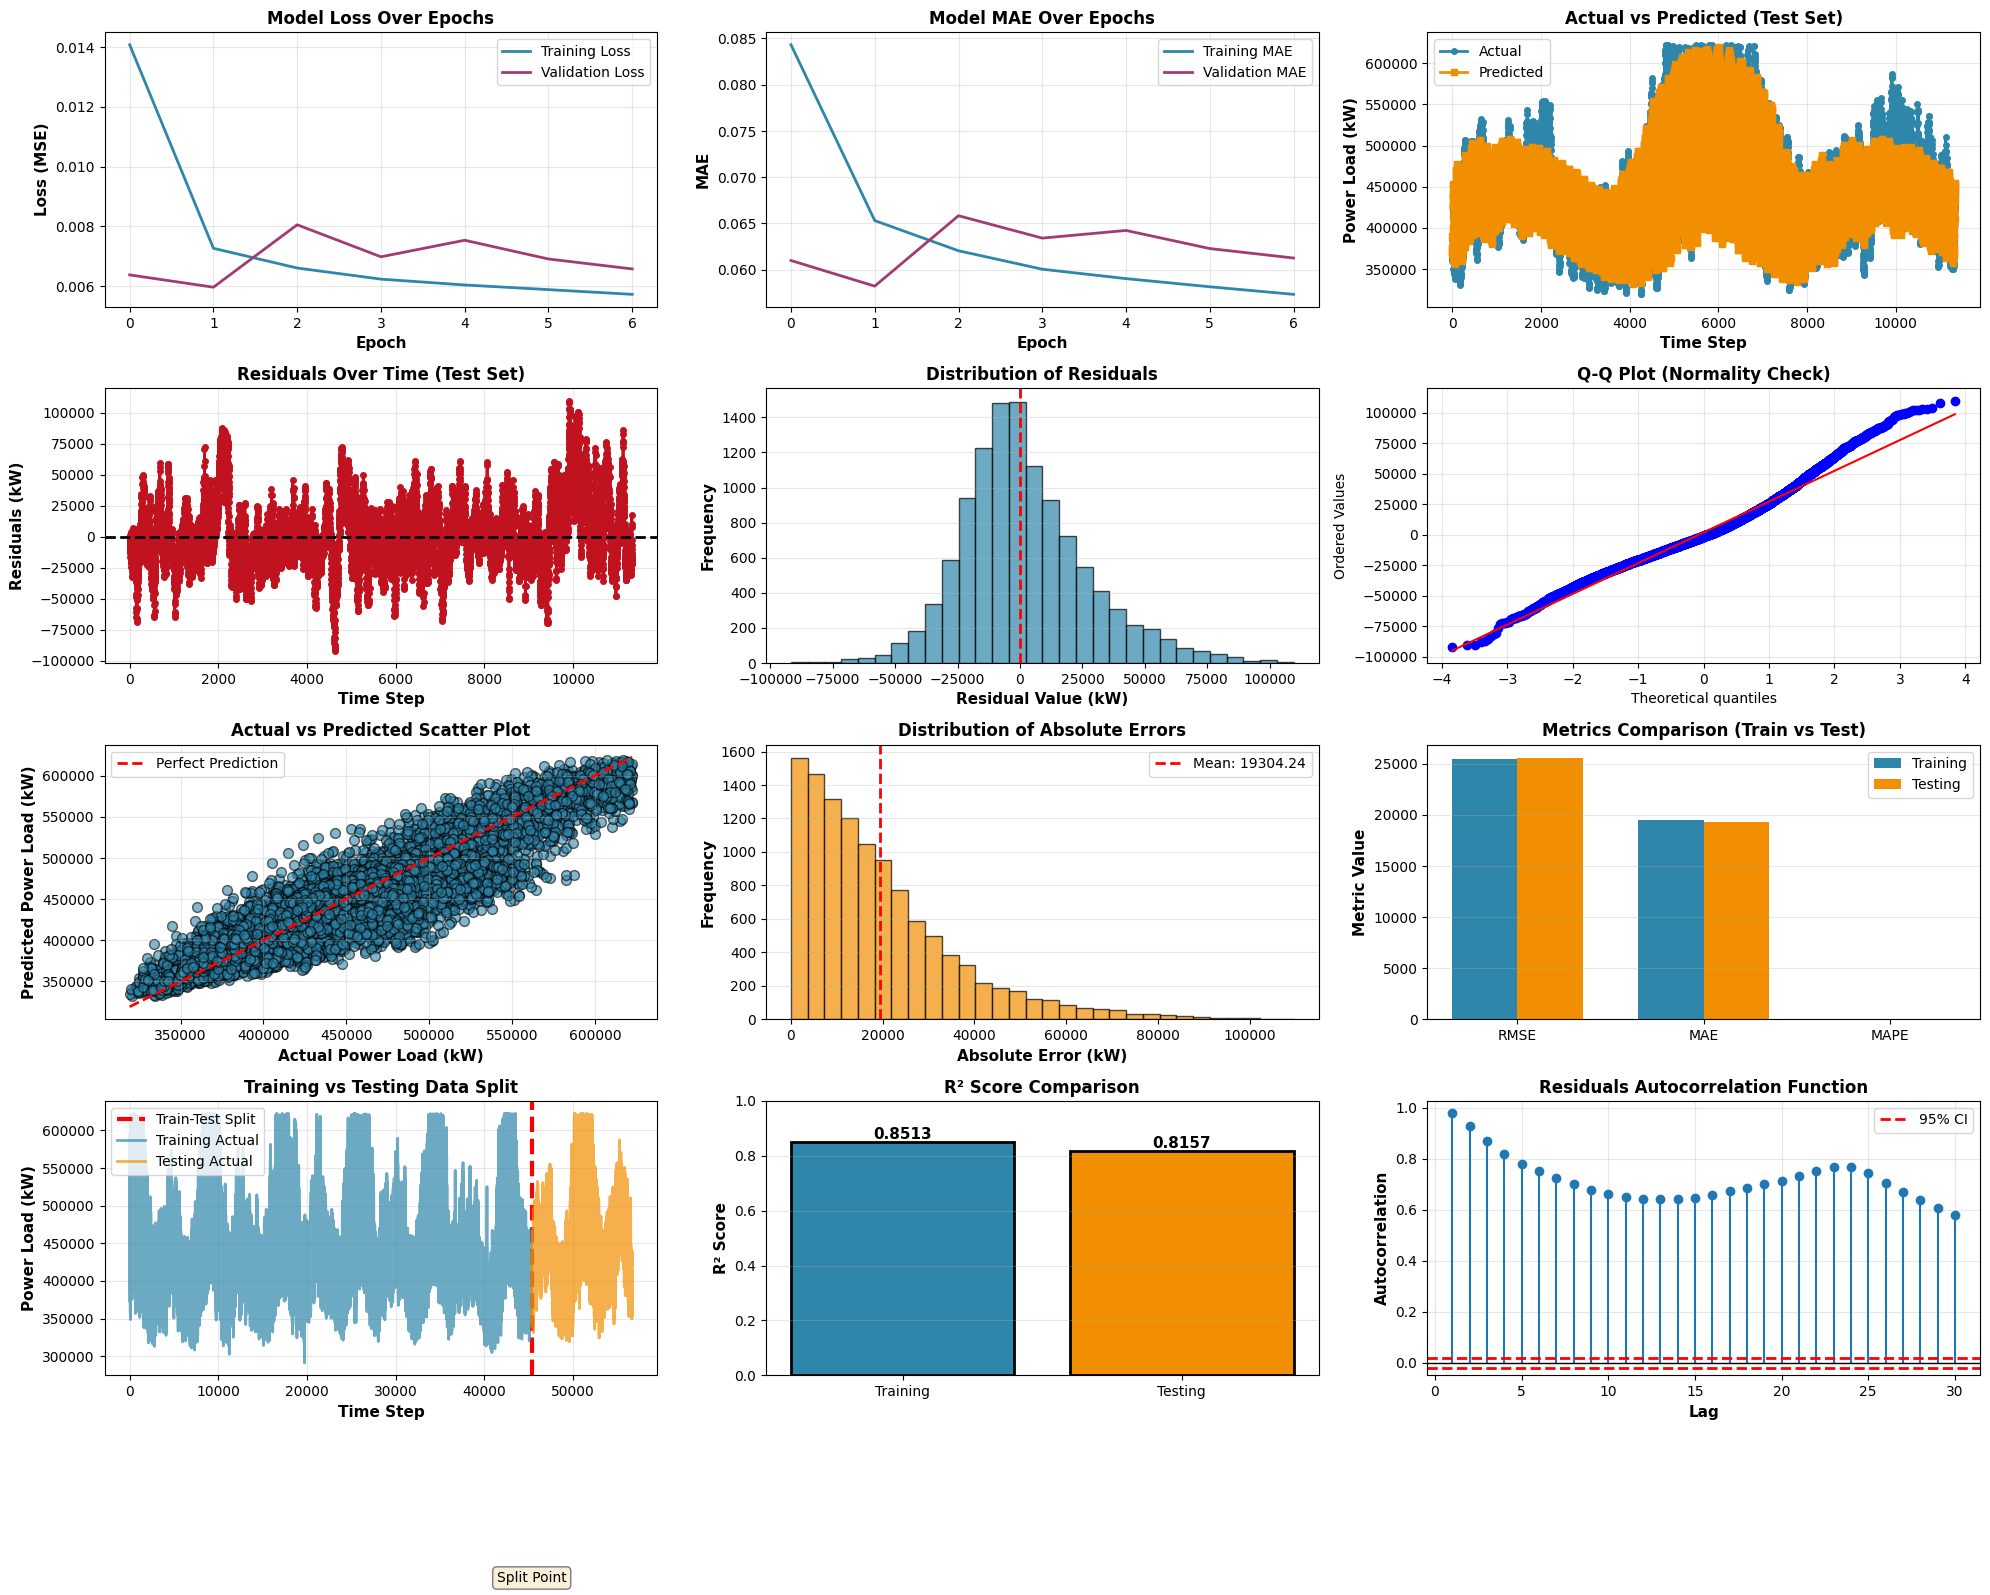

In [50]:
# ============================================
# STEP 11: COMPREHENSIVE VISUALIZATIONS
# ============================================
print("\n📊 STEP 11: GENERATING VISUALIZATIONS")
print("-" * 70)

fig = plt.figure(figsize=(20, 16))

# 1. Training History - Loss
ax1 = plt.subplot(4, 3, 1)
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2, color='#2E86AB')
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#A23B72')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
ax1.set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Training History - MAE
ax2 = plt.subplot(4, 3, 2)
ax2.plot(history.history['mae'], label='Training MAE', linewidth=2, color='#2E86AB')
ax2.plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='#A23B72')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('Model MAE Over Epochs', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Actual vs Predicted (Test Set)
ax3 = plt.subplot(4, 3, 3)
ax3.plot(y_test_actual, label='Actual', linewidth=2, color='#2E86AB', marker='o', markersize=4)
ax3.plot(y_test_pred, label='Predicted', linewidth=2, color='#F18F01', marker='s', markersize=4)
ax3.set_xlabel('Time Step', fontsize=11, fontweight='bold')
ax3.set_ylabel('Power Load (kW)', fontsize=11, fontweight='bold')
ax3.set_title('Actual vs Predicted (Test Set)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Residuals Test Set
ax4 = plt.subplot(4, 3, 4)
residuals = y_test_actual - y_test_pred
ax4.plot(residuals, linewidth=2, color='#C1121F', marker='o', markersize=4)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax4.set_xlabel('Time Step', fontsize=11, fontweight='bold')
ax4.set_ylabel('Residuals (kW)', fontsize=11, fontweight='bold')
ax4.set_title('Residuals Over Time (Test Set)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Residuals Distribution (Histogram)
ax5 = plt.subplot(4, 3, 5)
ax5.hist(residuals, bins=30, color='#2E86AB', edgecolor='black', alpha=0.7)
ax5.set_xlabel('Residual Value (kW)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax5.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax5.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Q-Q Plot
ax6 = plt.subplot(4, 3, 6)
stats.probplot(residuals, dist="norm", plot=ax6)
ax6.set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Actual vs Predicted Scatter
ax7 = plt.subplot(4, 3, 7)
ax7.scatter(y_test_actual, y_test_pred, alpha=0.6, s=50, color='#2E86AB', edgecolors='black')
ax7.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax7.set_xlabel('Actual Power Load (kW)', fontsize=11, fontweight='bold')
ax7.set_ylabel('Predicted Power Load (kW)', fontsize=11, fontweight='bold')
ax7.set_title('Actual vs Predicted Scatter Plot', fontsize=12, fontweight='bold')
ax7.legend(fontsize=10)
ax7.grid(True, alpha=0.3)

# 8. Error Distribution
ax8 = plt.subplot(4, 3, 8)
errors = np.abs(y_test_actual - y_test_pred)
ax8.hist(errors, bins=30, color='#F18F01', edgecolor='black', alpha=0.7)
ax8.set_xlabel('Absolute Error (kW)', fontsize=11, fontweight='bold')
ax8.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax8.set_title('Distribution of Absolute Errors', fontsize=12, fontweight='bold')
ax8.axvline(x=np.mean(errors), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(errors):.2f}')
ax8.legend(fontsize=10)
ax8.grid(True, alpha=0.3, axis='y')

# 9. Metrics Comparison
ax9 = plt.subplot(4, 3, 9)
metrics_names = ['RMSE', 'MAE', 'MAPE']
train_vals = [train_metrics['RMSE'], train_metrics['MAE'], train_metrics['MAPE']/10]
test_vals = [test_metrics['RMSE'], test_metrics['MAE'], test_metrics['MAPE']/10]
x = np.arange(len(metrics_names))
width = 0.35
ax9.bar(x - width/2, train_vals, width, label='Training', color='#2E86AB')
ax9.bar(x + width/2, test_vals, width, label='Testing', color='#F18F01')
ax9.set_ylabel('Metric Value', fontsize=11, fontweight='bold')
ax9.set_title('Metrics Comparison (Train vs Test)', fontsize=12, fontweight='bold')
ax9.set_xticks(x)
ax9.set_xticklabels(metrics_names)
ax9.legend(fontsize=10)
ax9.grid(True, alpha=0.3, axis='y')

# 10. Training vs Testing Split Visualization
ax10 = plt.subplot(4, 3, 10)
split_point = len(y_train_actual)
ax10.axvline(x=split_point, color='red', linestyle='--', linewidth=3, label='Train-Test Split')
ax10.text(split_point, ax10.get_ylim()[1]*0.95, 'Split Point', fontsize=10, ha='center', 
          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax10.plot(range(len(y_train_actual)), y_train_actual, label='Training Actual', 
         linewidth=2, color='#2E86AB', alpha=0.7)
ax10.plot(range(split_point, split_point + len(y_test_actual)), y_test_actual, 
         label='Testing Actual', linewidth=2, color='#F18F01', alpha=0.7)
ax10.set_xlabel('Time Step', fontsize=11, fontweight='bold')
ax10.set_ylabel('Power Load (kW)', fontsize=11, fontweight='bold')
ax10.set_title('Training vs Testing Data Split', fontsize=12, fontweight='bold')
ax10.legend(fontsize=10)
ax10.grid(True, alpha=0.3)

# 11. R² Score Visualization
ax11 = plt.subplot(4, 3, 11)
scores = [train_metrics['R2'], test_metrics['R2']]
colors_bar = ['#2E86AB', '#F18F01']
bars = ax11.bar(['Training', 'Testing'], scores, color=colors_bar, edgecolor='black', linewidth=2)
ax11.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax11.set_title('R² Score Comparison', fontsize=12, fontweight='bold')
ax11.set_ylim([0, 1])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax11.text(bar.get_x() + bar.get_width()/2., height,
             f'{scores[i]:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax11.grid(True, alpha=0.3, axis='y')

# 12. ACF-like: Residuals Autocorrelation
ax12 = plt.subplot(4, 3, 12)
residuals_acf = [np.corrcoef(residuals[:-i], residuals[i:])[0, 1] if i < len(residuals) else 0 
                  for i in range(1, min(31, len(residuals)//2))]
ax12.stem(range(1, len(residuals_acf)+1), residuals_acf, basefmt=' ')
ax12.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax12.axhline(y=1.96/np.sqrt(len(residuals)), color='red', linestyle='--', linewidth=2, label='95% CI')
ax12.axhline(y=-1.96/np.sqrt(len(residuals)), color='red', linestyle='--', linewidth=2)
ax12.set_xlabel('Lag', fontsize=11, fontweight='bold')
ax12.set_ylabel('Autocorrelation', fontsize=11, fontweight='bold')
ax12.set_title('Residuals Autocorrelation Function', fontsize=12, fontweight='bold')
ax12.legend(fontsize=10)
ax12.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Comprehensive visualization saved: 'model_performance_analysis.png'")
plt.show()

## 30-DAY AHEAD FORECAST

In [51]:
import pandas as pd
from datetime import datetime, timedelta
import numpy as np

# Current date
today = pd.to_datetime(datetime.now().date())

# End date (next 30 days)
end_date = today + timedelta(days=30)

# Generate a DatetimeIndex with 4-hour frequency
date_range = pd.date_range(start=today, end=end_date, freq='H')

# Create a sample DataFrame (optional)
forecast_next_30_days_df = pd.DataFrame({
    'datetime': date_range  # example random values
})

print(forecast_next_30_days_df.head(10))
print(f"\nTotal rows: {len(forecast_next_30_days_df)}")


             datetime
0 2025-11-26 00:00:00
1 2025-11-26 01:00:00
2 2025-11-26 02:00:00
3 2025-11-26 03:00:00
4 2025-11-26 04:00:00
5 2025-11-26 05:00:00
6 2025-11-26 06:00:00
7 2025-11-26 07:00:00
8 2025-11-26 08:00:00
9 2025-11-26 09:00:00

Total rows: 721


In [52]:
forecast_next_30_days_df

,datetime
0,2025-11-26 00:00:00
1,2025-11-26 01:00:00
2,2025-11-26 02:00:00
3,2025-11-26 03:00:00
4,2025-11-26 04:00:00
...,...
716,2025-12-25 20:00:00
717,2025-12-25 21:00:00
718,2025-12-25 22:00:00
719,2025-12-25 23:00:00


In [53]:
forecast_next_30_days_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  721 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 5.8 KB


In [54]:
# Ensure datetime is parsed
forecast_next_30_days_df['datetime'] = pd.to_datetime(forecast_next_30_days_df['datetime'], format='%d-%m-%Y %H:%M', errors='coerce')

In [55]:
# ===== CORE TIME FEATURES =====
forecast_next_30_days_df['hour'] = forecast_next_30_days_df['datetime'].dt.hour
forecast_next_30_days_df['day_of_week'] = forecast_next_30_days_df['datetime'].dt.dayofweek
forecast_next_30_days_df['day_of_month'] = forecast_next_30_days_df['datetime'].dt.day
forecast_next_30_days_df['day_of_year'] = forecast_next_30_days_df['datetime'].dt.dayofyear

In [56]:
forecast_next_30_days_df

,datetime,hour,day_of_week,day_of_month,day_of_year
0,2025-11-26 00:00:00,0,2,26,330
1,2025-11-26 01:00:00,1,2,26,330
2,2025-11-26 02:00:00,2,2,26,330
3,2025-11-26 03:00:00,3,2,26,330
4,2025-11-26 04:00:00,4,2,26,330
...,...,...,...,...,...
716,2025-12-25 20:00:00,20,3,25,359
717,2025-12-25 21:00:00,21,3,25,359
718,2025-12-25 22:00:00,22,3,25,359
719,2025-12-25 23:00:00,23,3,25,359


In [57]:
# ===== CYCLIC (PERIODIC) FEATURES =====
forecast_next_30_days_df['hour_sin'] = np.sin(2 * np.pi * forecast_next_30_days_df['hour'] / 24)
forecast_next_30_days_df['hour_cos'] = np.cos(2 * np.pi * forecast_next_30_days_df['hour'] / 24)
forecast_next_30_days_df['dayofweek_sin'] = np.sin(2 * np.pi * forecast_next_30_days_df['day_of_week'] / 7)
forecast_next_30_days_df['dayofweek_cos'] = np.cos(2 * np.pi * forecast_next_30_days_df['day_of_week'] / 7)
forecast_next_30_days_df['dayofmonth_sin'] = np.sin(2 * np.pi * (forecast_next_30_days_df['day_of_month'] - 1) / 31)
forecast_next_30_days_df['dayofmonth_cos'] = np.cos(2 * np.pi * (forecast_next_30_days_df['day_of_month'] - 1) / 31)
forecast_next_30_days_df['dayofyear_sin'] = np.sin(2 * np.pi * (forecast_next_30_days_df['day_of_year'] - 1) / 365)
forecast_next_30_days_df['dayofyear_cos'] = np.cos(2 * np.pi * (forecast_next_30_days_df['day_of_year'] - 1) / 365)

In [58]:
forecast_next_30_days_df

,datetime,hour,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
0,2025-11-26 00:00:00,0,2,26,330,0.000000,1.000000,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
1,2025-11-26 01:00:00,1,2,26,330,0.258819,0.965926,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
2,2025-11-26 02:00:00,2,2,26,330,0.500000,0.866025,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
3,2025-11-26 03:00:00,3,2,26,330,0.707107,0.707107,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
4,2025-11-26 04:00:00,4,2,26,330,0.866025,0.500000,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,2025-12-25 20:00:00,20,3,25,359,-0.866025,0.500000,0.433884,-0.900969,-0.988468,0.151428,-0.120208,0.992749
717,2025-12-25 21:00:00,21,3,25,359,-0.707107,0.707107,0.433884,-0.900969,-0.988468,0.151428,-0.120208,0.992749
718,2025-12-25 22:00:00,22,3,25,359,-0.500000,0.866025,0.433884,-0.900969,-0.988468,0.151428,-0.120208,0.992749
719,2025-12-25 23:00:00,23,3,25,359,-0.258819,0.965926,0.433884,-0.900969,-0.988468,0.151428,-0.120208,0.992749


In [59]:
# forecast_next_30_days_df.drop(columns=['hour', 'day_of_week', 'day_of_month','day_of_year'], axis=1, inplace=True)

In [60]:
forecast_next_30_days_df.set_index('datetime', inplace=True)

In [61]:
forecast_next_30_days_df

,hour,day_of_week,day_of_month,day_of_year,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos
datetime,,,,,,,,,,,,
2025-11-26 00:00:00,0,2,26,330,0.000000,1.000000,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
2025-11-26 01:00:00,1,2,26,330,0.258819,0.965926,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
2025-11-26 02:00:00,2,2,26,330,0.500000,0.866025,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
2025-11-26 03:00:00,3,2,26,330,0.707107,0.707107,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
2025-11-26 04:00:00,4,2,26,330,0.866025,0.500000,0.974928,-0.222521,-0.937752,0.347305,-0.580800,0.814046
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25 20:00:00,20,3,25,359,-0.866025,0.500000,0.433884,-0.900969,-0.988468,0.151428,-0.120208,0.992749
2025-12-25 21:00:00,21,3,25,359,-0.707107,0.707107,0.433884,-0.900969,-0.988468,0.151428,-0.120208,0.992749
2025-12-25 22:00:00,22,3,25,359,-0.500000,0.866025,0.433884,-0.900969,-0.988468,0.151428,-0.120208,0.992749


In [62]:
forecast_next_30_days = forecast_next_30_days_df.copy()


In [63]:
seq_length=7

In [64]:
import numpy as np

def create_sequences(X, seq_length=7):
    X_seq = []
    for i in range(len(X) - seq_length):
        # take a sliding window of length seq_length
        X_seq.append(X.iloc[i:i+seq_length].values)
    return np.array(X_seq)

In [65]:
seq_length = 7
X_30_days_seq = create_sequences(forecast_next_30_days, seq_length)

print(X_30_days_seq.shape)
# → (num_sequences, 7, num_features)

(714, 7, 12)


In [66]:
X_30_days_seq

array([[[ 0.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        [ 1.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        [ 2.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        ...,
        [ 4.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        [ 5.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        [ 6.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609]],

       [[ 1.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        [ 2.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        [ 3.        ,  2.        , 26.        , ...,  0.34730525,
         -0.58080027,  0.81404609],
        ...,
        [ 5.        ,  2.        , 26.        , ...,  

In [67]:
X_30_days_seq[1]

array([[ 1.00000000e+00,  2.00000000e+00,  2.60000000e+01,
         3.30000000e+02,  2.58819045e-01,  9.65925826e-01,
         9.74927912e-01, -2.22520934e-01, -9.37752132e-01,
         3.47305253e-01, -5.80800273e-01,  8.14046094e-01],
       [ 2.00000000e+00,  2.00000000e+00,  2.60000000e+01,
         3.30000000e+02,  5.00000000e-01,  8.66025404e-01,
         9.74927912e-01, -2.22520934e-01, -9.37752132e-01,
         3.47305253e-01, -5.80800273e-01,  8.14046094e-01],
       [ 3.00000000e+00,  2.00000000e+00,  2.60000000e+01,
         3.30000000e+02,  7.07106781e-01,  7.07106781e-01,
         9.74927912e-01, -2.22520934e-01, -9.37752132e-01,
         3.47305253e-01, -5.80800273e-01,  8.14046094e-01],
       [ 4.00000000e+00,  2.00000000e+00,  2.60000000e+01,
         3.30000000e+02,  8.66025404e-01,  5.00000000e-01,
         9.74927912e-01, -2.22520934e-01, -9.37752132e-01,
         3.47305253e-01, -5.80800273e-01,  8.14046094e-01],
       [ 5.00000000e+00,  2.00000000e+00,  2.6000000

In [68]:
print(f"Input shape: {X_30_days_seq.shape}")

Input shape: (714, 7, 12)


In [ ]:
# Make predictions
predictions = model.predict(X_30_days_seq, verbose=1)

InvalidArgumentError: Graph execution error:

Detected at node sequential_1/lstm_1/while/body/_1/sequential_1/lstm_1/while/lstm_cell_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [32,12], In[1]: [8,512]
	 [[{{node sequential_1/lstm_1/while/body/_1/sequential_1/lstm_1/while/lstm_cell_1/MatMul}}]] [Op:__inference_one_step_on_data_distributed_54753]

In [ ]:
predictions.shape

(714, 1)

In [ ]:
predictions

array([[0.27462456],
       [0.25457278],
       [0.25039813],
       [0.26291114],
       [0.3148972 ],
       [0.38704765],
       [0.46404302],
       [0.5263971 ],
       [0.55929047],
       [0.5595698 ],
       [0.5402075 ],
       [0.51765317],
       [0.50085306],
       [0.49270934],
       [0.49423826],
       [0.50662726],
       [0.53126377],
       [0.5627871 ],
       [0.57965183],
       [0.56352276],
       [0.51434815],
       [0.44678885],
       [0.37397477],
       [0.3067012 ],
       [0.2722943 ],
       [0.25107604],
       [0.24350712],
       [0.25153953],
       [0.29103658],
       [0.3604153 ],
       [0.436112  ],
       [0.49835366],
       [0.536535  ],
       [0.5443316 ],
       [0.52826685],
       [0.50343263],
       [0.48233038],
       [0.46918166],
       [0.46824273],
       [0.48094797],
       [0.50496876],
       [0.53351974],
       [0.5469944 ],
       [0.5316474 ],
       [0.48796347],
       [0.42596725],
       [0.35837716],
       [0.295

In [ ]:
# Convert predictions array to DataFrame please make sure this prediction add input ferures and give combine datafream
pred_df = pd.DataFrame(predictions, columns=['scaled_predictions'])
print(pred_df.head())

   scaled_predictions
0            0.274625
1            0.254573
2            0.250398
3            0.262911
4            0.314897


In [ ]:
pred_df

,scaled_predictions
0,0.274625
1,0.254573
2,0.250398
3,0.262911
4,0.314897
...,...
709,0.590906
710,0.585892
711,0.599230
712,0.626504


In [ ]:
# Assuming you used MinMaxScaler during training
from sklearn.preprocessing import MinMaxScaler

# Reuse the same scaler fitted on your training target
# Example: scaler_y was fit on your target column originally
original_predictions = scaler_y.inverse_transform(predictions)

# Convert to DataFrame
preddf = pd.DataFrame(original_predictions, columns=['predictions'])
print(preddf.head())

    predictions
0  382114.53125
1  375466.15625
2  374082.03125
3  378230.81250
4  395467.31250


In [ ]:
# Get the corresponding datetime indices
prediction_start_idx = seq_length
prediction_datetimes = forecast_next_30_days_df.index[prediction_start_idx:prediction_start_idx + len(original_predictions)]


In [ ]:
prediction_datetimes

DatetimeIndex(['2025-11-13 07:00:00', '2025-11-13 08:00:00',
               '2025-11-13 09:00:00', '2025-11-13 10:00:00',
               '2025-11-13 11:00:00', '2025-11-13 12:00:00',
               '2025-11-13 13:00:00', '2025-11-13 14:00:00',
               '2025-11-13 15:00:00', '2025-11-13 16:00:00',
               ...
               '2025-12-12 15:00:00', '2025-12-12 16:00:00',
               '2025-12-12 17:00:00', '2025-12-12 18:00:00',
               '2025-12-12 19:00:00', '2025-12-12 20:00:00',
               '2025-12-12 21:00:00', '2025-12-12 22:00:00',
               '2025-12-12 23:00:00', '2025-12-13 00:00:00'],
              dtype='datetime64[ns]', name='datetime', length=714, freq=None)

In [ ]:
# Create predictions DataFrame with proper datetime alignment
pred_data = pd.DataFrame({
    'datetime': prediction_datetimes,
    'prediction': original_predictions.flatten()
})
pred_data.set_index('datetime', inplace=True)

print("=" * 60)
print("PREDICTIONS DATAFRAME")
print("=" * 60)
print(pred_data.head(10))
print(f"\nTotal predictions: {len(pred_data)}")
print()


PREDICTIONS DATAFRAME
                       prediction
datetime                         
2025-11-13 07:00:00  382114.53125
2025-11-13 08:00:00  375466.15625
2025-11-13 09:00:00  374082.03125
2025-11-13 10:00:00  378230.81250
2025-11-13 11:00:00  395467.31250
2025-11-13 12:00:00  419389.53125
2025-11-13 13:00:00  444918.09375
2025-11-13 14:00:00  465592.21875
2025-11-13 15:00:00  476498.34375
2025-11-13 16:00:00  476590.93750

Total predictions: 714



In [ ]:
# ===============================
# 7. COMBINE PREDICTIONS WITH INPUT FEATURES
# ===============================
# Merge predictions with the corresponding input features
combined_df = forecast_next_30_days_df.loc[prediction_datetimes].copy()
combined_df['prediction'] = pred_data['prediction']

print("=" * 60)
print("COMBINED DATAFRAME (Features + Predictions)")
print("=" * 60)
print(combined_df.head(10))
print()

COMBINED DATAFRAME (Features + Predictions)
                         hour_sin  hour_cos  dayofweek_sin  dayofweek_cos  \
datetime                                                                    
2025-11-13 07:00:00  9.659258e-01 -0.258819       0.433884      -0.900969   
2025-11-13 08:00:00  8.660254e-01 -0.500000       0.433884      -0.900969   
2025-11-13 09:00:00  7.071068e-01 -0.707107       0.433884      -0.900969   
2025-11-13 10:00:00  5.000000e-01 -0.866025       0.433884      -0.900969   
2025-11-13 11:00:00  2.588190e-01 -0.965926       0.433884      -0.900969   
2025-11-13 12:00:00  1.224647e-16 -1.000000       0.433884      -0.900969   
2025-11-13 13:00:00 -2.588190e-01 -0.965926       0.433884      -0.900969   
2025-11-13 14:00:00 -5.000000e-01 -0.866025       0.433884      -0.900969   
2025-11-13 15:00:00 -7.071068e-01 -0.707107       0.433884      -0.900969   
2025-11-13 16:00:00 -8.660254e-01 -0.500000       0.433884      -0.900969   

                     dayofmonth

In [ ]:
combined_df

,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,prediction
datetime,,,,,,,,,
2025-11-13 07:00:00,0.965926,-0.258819,0.433884,-0.900969,0.651372,-0.758758,-0.746972,0.664855,382114.53125
2025-11-13 08:00:00,0.866025,-0.500000,0.433884,-0.900969,0.651372,-0.758758,-0.746972,0.664855,375466.15625
2025-11-13 09:00:00,0.707107,-0.707107,0.433884,-0.900969,0.651372,-0.758758,-0.746972,0.664855,374082.03125
2025-11-13 10:00:00,0.500000,-0.866025,0.433884,-0.900969,0.651372,-0.758758,-0.746972,0.664855,378230.81250
2025-11-13 11:00:00,0.258819,-0.965926,0.433884,-0.900969,0.651372,-0.758758,-0.746972,0.664855,395467.31250
...,...,...,...,...,...,...,...,...,...
2025-12-12 20:00:00,-0.866025,0.500000,-0.433884,-0.900969,0.790776,-0.612106,-0.337523,0.941317,486980.84375
2025-12-12 21:00:00,-0.707107,0.707107,-0.433884,-0.900969,0.790776,-0.612106,-0.337523,0.941317,485318.50000
2025-12-12 22:00:00,-0.500000,0.866025,-0.433884,-0.900969,0.790776,-0.612106,-0.337523,0.941317,489740.71875


In [ ]:
# ===============================
# 8. SUMMARY STATISTICS
# ===============================
print("=" * 60)
print("30-DAY FORECAST SUMMARY")
print("=" * 60)
print(f"Forecast Period: {combined_df.index[0]} to {combined_df.index[-1]}")
print(f"Total Predictions: {len(combined_df)}")
print(f"\nPrediction Statistics:")
print(f"  Mean: {combined_df['prediction'].mean():.2f}")
print(f"  Std: {combined_df['prediction'].std():.2f}")
print(f"  Min: {combined_df['prediction'].min():.2f}")
print(f"  Max: {combined_df['prediction'].max():.2f}")
print()

30-DAY FORECAST SUMMARY
Forecast Period: 2025-11-13 07:00:00 to 2025-12-13 00:00:00
Total Predictions: 714

Prediction Statistics:
  Mean: 433617.56
  Std: 41587.37
  Min: 353107.38
  Max: 521630.78



In [ ]:
# ===============================
# SAVE THE COMPLETE MODEL
# ===============================
model.save("lstm_energy_forecast_model.h5")   # or .keras extension
print("✅ Model saved successfully as lstm_energy_forecast_model.h5")

✅ Model saved successfully as lstm_energy_forecast_model.h5
